In [2]:
import pandas as pd
import numpy as np

from pathlib import Path

base_path = Path('/media/Volume/data/ECG_high_intensity_exercise')
segments = base_path / 'ecg_segments'
manual_annotations = base_path / 'manual_annotations'

# list all the files in the directory
files = list(segments.glob('*.csv'))

# open each file
list_of_dataframes = []
for file in files:
    if file.is_file():
        if '_raw_' in file.name:
            continue
        df = pd.read_csv(file, header=None)
        # rename the column 0 to the file name without extension
        df.columns = [file.stem, '']
        list_of_dataframes.append(df)

# concatenate all dataframes into one where each column is a row instead
df = pd.concat(list_of_dataframes, axis=1)
df = df / 1000
# remove columns with all NaN values

# order columns by name
df = df.dropna(axis=1, how='all').T
df.head()

import re, glob

pattern = re.compile(r'(?<=sub)\d+')

subject_ids = [f for f in df.index if int(pattern.search(f).group()) > 13]

# keep only these subject IDs
df = df.loc[subject_ids]

df.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
ecg_sub16_seg1,-0.003,-0.001,-0.001,0.000,0.000,0.000,0.000,0.001,0.002,0.003,...,-0.001,-0.004,-0.009,-0.016,-0.023,-0.026,-0.029,-0.029,-0.029,-0.028
ecg_sub20_seg2,0.146,0.118,0.049,-0.004,-0.044,-0.066,-0.070,-0.071,-0.070,-0.065,...,-0.108,-0.087,-0.064,-0.044,-0.030,-0.017,-0.008,-0.001,0.000,0.000
ecg_sub17_seg5,0.112,0.046,-0.008,-0.028,-0.029,-0.027,-0.025,-0.023,-0.017,-0.014,...,-0.017,-0.011,-0.005,0.000,0.004,0.006,0.008,0.011,0.014,0.016
ecg_sub14_seg3,0.584,0.511,0.450,0.406,0.355,0.309,0.267,0.226,0.191,0.163,...,0.000,0.000,0.000,0.001,0.002,0.006,0.011,0.016,0.020,0.024
ecg_sub19_seg1,-0.023,-0.026,-0.030,-0.034,-0.040,-0.047,-0.054,-0.050,-0.011,0.062,...,-0.032,-0.037,-0.045,-0.055,-0.063,-0.055,-0.011,0.061,0.158,0.211


In [3]:
# get list of columns
columns = df.index.tolist()
print(columns)

r_peaks = []
# for each column get the annotations of r-peaks on manual annotation
for column in columns:
    # get the file name
    file_name = column + '_labels.csv'
    # read the manual annotations
    manual_annotation_file = manual_annotations / file_name
    if manual_annotation_file.is_file():
        manual_df = pd.read_csv(manual_annotation_file, header=None)
        # set the column name
        manual_df.columns = [file_name, 1, 2]
        # remove the second column
        # get the r-peaks
        r_peaks.append(manual_df[file_name])
    else:
        print(f'File: {file_name} not found in manual annotations')

# create a new dataframe with the r-peaks
r_peaks_df = pd.DataFrame(r_peaks).T

r_peaks_df.head()


['ecg_sub16_seg1', 'ecg_sub20_seg2', 'ecg_sub17_seg5', 'ecg_sub14_seg3', 'ecg_sub19_seg1', 'ecg_sub21_seg4', 'ecg_sub22_seg3', 'ecg_sub18_seg5', 'ecg_sub18_seg2', 'ecg_sub17_seg4', 'ecg_sub14_seg2', 'ecg_sub20_seg1', 'ecg_sub20_seg3', 'ecg_sub14_seg5', 'ecg_sub19_seg5', 'ecg_sub15_seg1', 'ecg_sub17_seg1', 'ecg_sub19_seg4', 'ecg_sub16_seg3', 'ecg_sub16_seg2', 'ecg_sub15_seg4', 'ecg_sub17_seg2', 'ecg_sub21_seg2', 'ecg_sub21_seg5', 'ecg_sub14_seg1', 'ecg_sub16_seg4', 'ecg_sub20_seg4', 'ecg_sub22_seg2', 'ecg_sub20_seg5', 'ecg_sub19_seg3', 'ecg_sub15_seg2', 'ecg_sub22_seg4', 'ecg_sub22_seg1', 'ecg_sub22_seg5', 'ecg_sub14_seg4', 'ecg_sub21_seg1', 'ecg_sub18_seg1', 'ecg_sub18_seg4', 'ecg_sub15_seg5', 'ecg_sub21_seg3', 'ecg_sub19_seg2', 'ecg_sub18_seg3', 'ecg_sub15_seg3', 'ecg_sub17_seg3', 'ecg_sub16_seg5']


,ecg_sub16_seg1_labels.csv,ecg_sub20_seg2_labels.csv,ecg_sub17_seg5_labels.csv,ecg_sub14_seg3_labels.csv,ecg_sub19_seg1_labels.csv,ecg_sub21_seg4_labels.csv,ecg_sub22_seg3_labels.csv,ecg_sub18_seg5_labels.csv,ecg_sub18_seg2_labels.csv,ecg_sub17_seg4_labels.csv,...,ecg_sub21_seg1_labels.csv,ecg_sub18_seg1_labels.csv,ecg_sub18_seg4_labels.csv,ecg_sub15_seg5_labels.csv,ecg_sub21_seg3_labels.csv,ecg_sub19_seg2_labels.csv,ecg_sub18_seg3_labels.csv,ecg_sub15_seg3_labels.csv,ecg_sub17_seg3_labels.csv,ecg_sub16_seg5_labels.csv
0,81.0,93.0,82.0,33.0,13.0,27.0,6.0,55.0,8.0,68.0,...,6.0,86.0,51.0,13.0,9.0,62.0,25.0,22.0,17.0,69.0
1,185.0,188.0,166.0,110.0,104.0,110.0,89.0,148.0,95.0,143.0,...,99.0,177.0,131.0,99.0,93.0,149.0,107.0,100.0,92.0,167.0
2,290.0,282.0,249.0,187.0,194.0,194.0,173.0,241.0,181.0,218.0,...,192.0,268.0,213.0,186.0,178.0,236.0,190.0,178.0,168.0,264.0
3,394.0,377.0,332.0,264.0,286.0,277.0,257.0,334.0,268.0,292.0,...,284.0,358.0,294.0,274.0,263.0,323.0,272.0,255.0,243.0,361.0
4,498.0,471.0,414.0,341.0,377.0,360.0,342.0,427.0,355.0,367.0,...,377.0,450.0,376.0,360.0,347.0,410.0,355.0,333.0,319.0,460.0


In [4]:
# get one sample from the dataset
import numpy as np
from torch.utils.data import DataLoader
from torch.nn import functional as F
from dataset.generic_utils import get_transforms

from dataset.mit_bih import ECGMITBIHDataset
from dataset.code_dataset import ECGCODE15Dataset
from dataset.mimic_iv import ECGMIMICDataset
from dataset.chapman import ECGChapmanDataset
from dataset.cpsc2018 import ECGCPSC2018Dataset
from dataset.deepbeat import DeepBeatDataset
from dataset.sleep_apnea import ECGSleepApneaDataset
class DatasetArgs:  
    def __init__(self):
        self.data_folder_code15 = '/media/Volume/data/CODE15/processed'
        self.labels_file_code15 = '/media/Volume/data/CODE15/processed/exams_filtered.csv'
        self.data_folder_mimic=  '/media/Volume/data/MIMIC_IV/'
        self.labels_file_mimic=  '/media/Volume/data/MIMIC_IV/exams_filtered.csv'
        self.data_folder_chapman = '/media/Volume/data/ChapmanNingbo/1.0.0/'
        self.labels_file_chapman = '/media/Volume/data/ChapmanNingbo/1.0.0/exams_filtered.csv'
        self.data_folder_cpsc2018 = '/media/Volume/data/CPSC2018/'
        self.labels_file_cpsc2018 = '/media/Volume/data/CPSC2018/exams_filtered.csv'
        self.data_folder_sleep_apnea = '/media/Volume/data/sleep_apnea/physionet_apnea/'
        self.patch_size = 25
        self.normalize = False
        self.leads = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
        self.bidirectional = True
        self.global_random_crop = 0.9
        self.local_random_crop = 0.2
        self.random_drop_leads = 0.1
        self.random_surrogate_prob = 0.
        self.random_jitter_prob = 0.5
        self.random_resample = True
        self.use_teacher_student = True
        self.random_crop=0.9
        self.strategy = 'masked_token_prediction'
        self.n_global_view=2
        self.n_local_view=4
        self.sampling_freq=100
        self.nk_clean=False
        self.shift_baseline_wander_in_sample=False
        self.shuffle_baseline_wander_in_batch=True
        self.batch_size = 32
        self.num_workers = 1
        self.random_change_amplitude = 0.5
        self.task='multilabel'
        self.standardize = False
        self.low_pass_filter = None
        self.high_pass_filter = None
        self.max_length_signal = 7200
        self.use_ecg_jepa = False
        self.keep_lead_II = True
        self.data_folder_deepbeat = '/media/Volume/data/DeepBeat_PPG/'
        self.discard_bad_samples = False
        self.discard_augmented_samples = False
        self.window_size_train = 6000
        self.window_size_val = 6000
        self.is_recurrent = False

config = DatasetArgs()

# dataset = ECGCODE15Dataset(config, global_augmentations=get_transforms(config, split='train', type='global'), local_augmentations=get_transforms(config, split='train', type='local'))
dataset = ECGCPSC2018Dataset(config, split='train')
dataset_val = ECGCPSC2018Dataset(config, split='val')
dataset_test = ECGCPSC2018Dataset(config, split='test')

INFO: Pandarallel will run on 16 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
using leads : ['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']


Processing labels: 100%|██████████| 4995/4995 [00:03<00:00, 1325.20it/s]


Label 426783006 has 684 samples
Label 284470004 has 446 samples
Label 164884008 has 497 samples
Label 164909002 has 160 samples
Label 164889003 has 865 samples
Label 59118001 has 1353 samples
Label 429622005 has 626 samples
Label 270492004 has 521 samples
Label 164931005 has 175 samples
loaded 4995 records
using leads : ['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']


Processing labels: 100%|██████████| 999/999 [00:00<00:00, 1324.82it/s]


Label 426783006 has 121 samples
Label 284470004 has 90 samples
Label 164884008 has 118 samples
Label 164909002 has 47 samples
Label 164889003 has 194 samples
Label 59118001 has 264 samples
Label 429622005 has 117 samples
Label 270492004 has 111 samples
Label 164931005 has 22 samples
loaded 999 records
using leads : ['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']


Processing labels: 100%|██████████| 877/877 [00:00<00:00, 1328.42it/s]

Label 426783006 has 113 samples
Label 284470004 has 80 samples
Label 164884008 has 84 samples
Label 164909002 has 29 samples
Label 164889003 has 160 samples
Label 59118001 has 238 samples
Label 429622005 has 126 samples
Label 270492004 has 89 samples
Label 164931005 has 23 samples
loaded 877 records


In [5]:
tot_len = []
for sample in dataset:
    tot_len.append(sample['signal'].shape[0])

for sample in dataset_val:
    tot_len.append(sample['signal'].shape[0])

for sample in dataset_test:
    tot_len.append(sample['signal'].shape[0])

avg_len = np.array(tot_len).mean()
print('Average length:', (avg_len / 100))
tot_len = np.array(tot_len).sum()
tot_len = (tot_len / 100) / 3600
print('Total length:', tot_len)

Average length: 15.945000727696115
Total length: 30.432805555555557


In [6]:
import numpy as np
import pandas as pd

# load /media/Volume/data/DeepBeat_PPG/train.npz 

sample_train = np.load('/media/Volume/data/DeepBeat_PPG/train.npz', allow_pickle=True)
sample_val = np.load('/media/Volume/data/DeepBeat_PPG/validate.npz', allow_pickle=True)
sample_test = np.load('/media/Volume/data/DeepBeat_PPG/test.npz', allow_pickle=True)

# load as df
sample_train_df = pd.DataFrame(sample_train['parameters'])
sample_val_df = pd.DataFrame(sample_val['parameters'])
sample_test_df = pd.DataFrame(sample_test['parameters'])

In [7]:
sample_train_df.head()

uniques_1 = sample_train_df[1].unique()
print(uniques_1)

[' b' ' a' ' c' ' d' ' e' ' f' ' g' ' h']


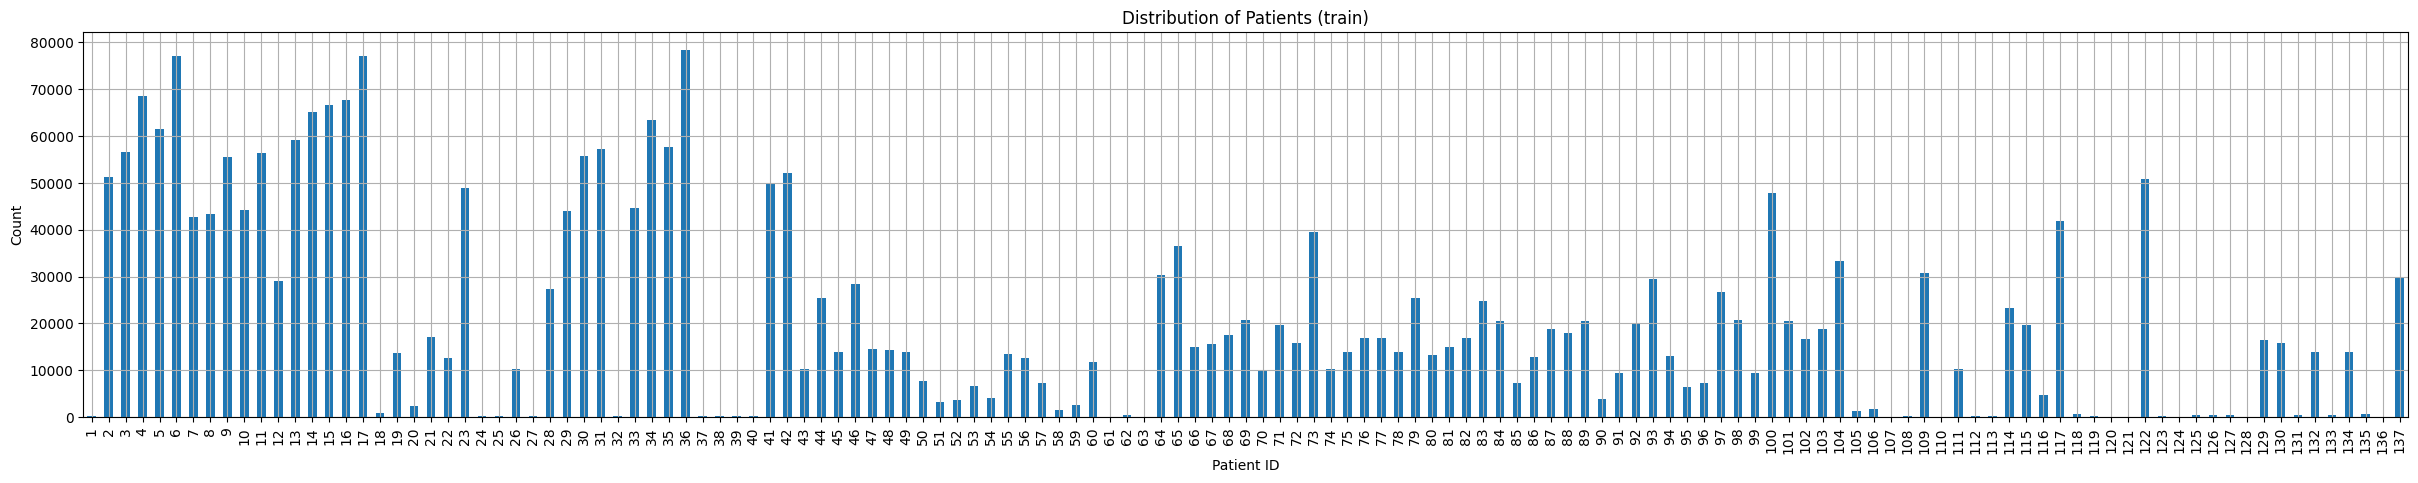

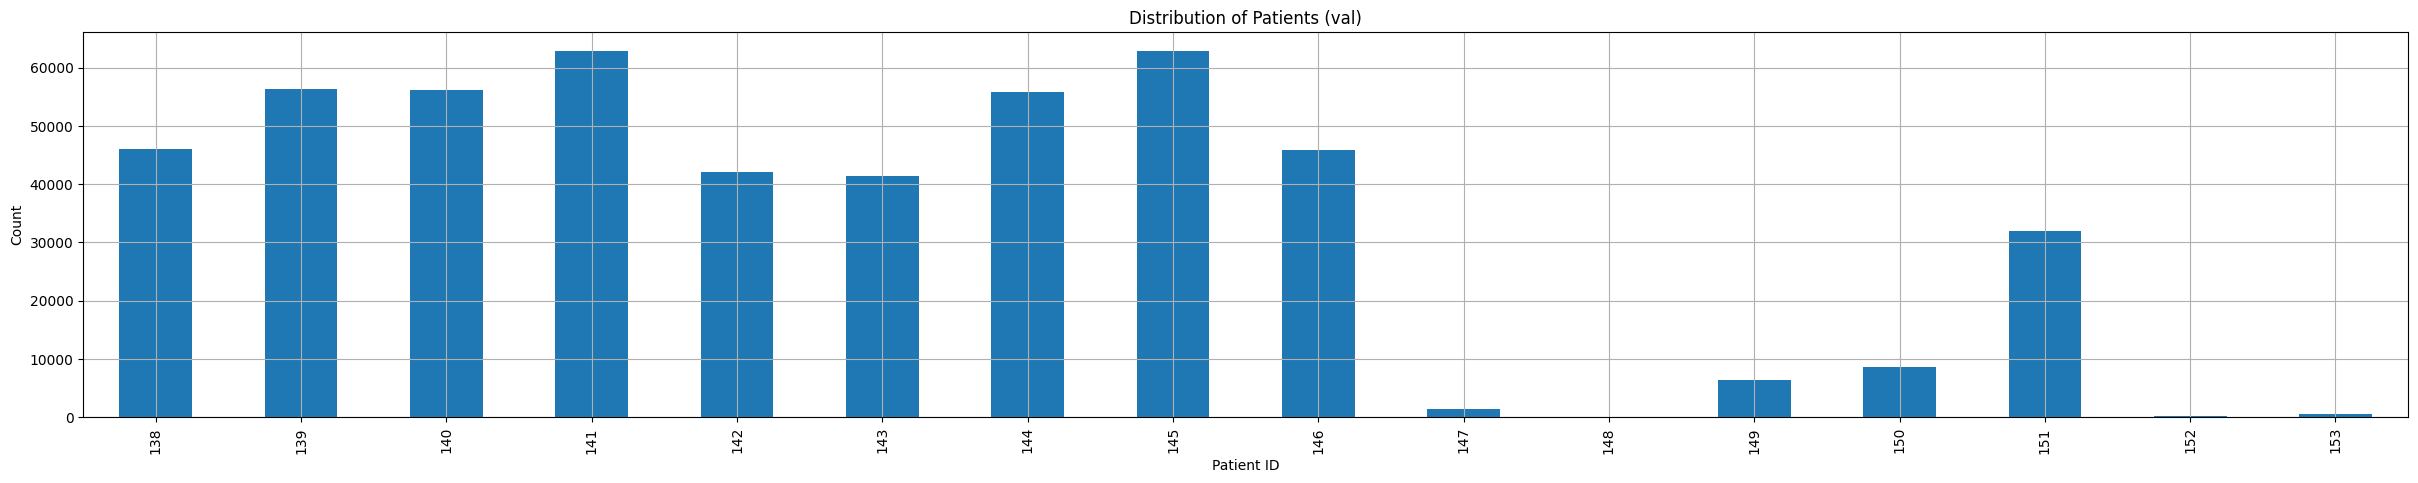

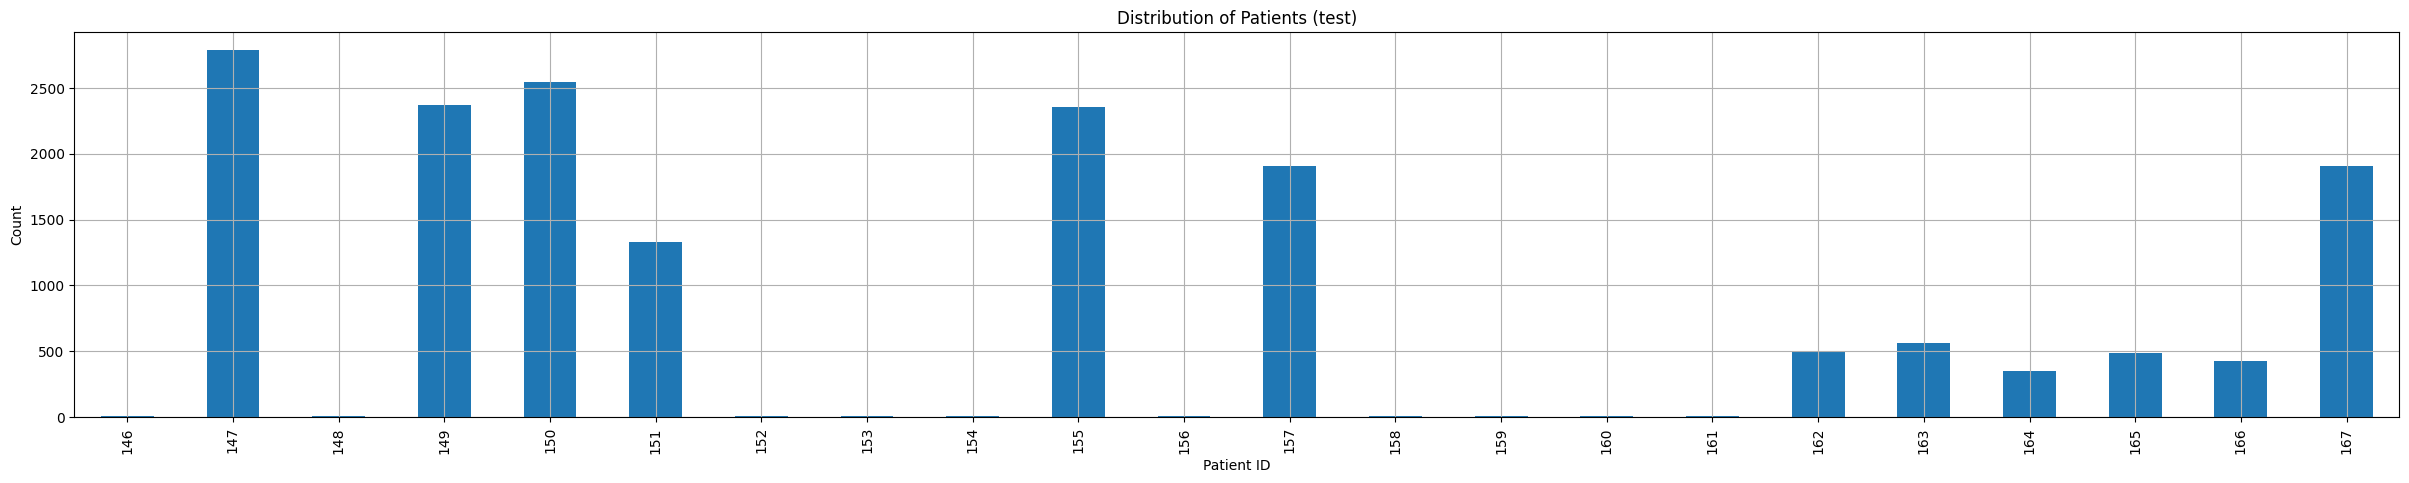

In [8]:
count_patients = sample_train_df[2].value_counts()
count_patients_val = sample_val_df[2].value_counts()
count_patients_test = sample_test_df[2].value_counts()
# order by index
count_patients = count_patients.sort_index()
count_patients_val = count_patients_val.sort_index()
count_patients_test = count_patients_test.sort_index()

# plot the distribution of patients
import matplotlib.pyplot as plt
plt.figure(figsize=(30, 5))
count_patients.plot(kind='bar')
plt.title('Distribution of Patients (train)')
plt.xlabel('Patient ID')
plt.ylabel('Count')
plt.grid()
plt.show()

plt.figure(figsize=(30, 5))
count_patients_val.plot(kind='bar')
plt.title('Distribution of Patients (val)')
plt.xlabel('Patient ID')
plt.ylabel('Count')
plt.grid()
plt.show()

plt.figure(figsize=(30, 5))
count_patients_test.plot(kind='bar')
plt.title('Distribution of Patients (test)')
plt.xlabel('Patient ID')
plt.ylabel('Count')
plt.grid()
plt.show()


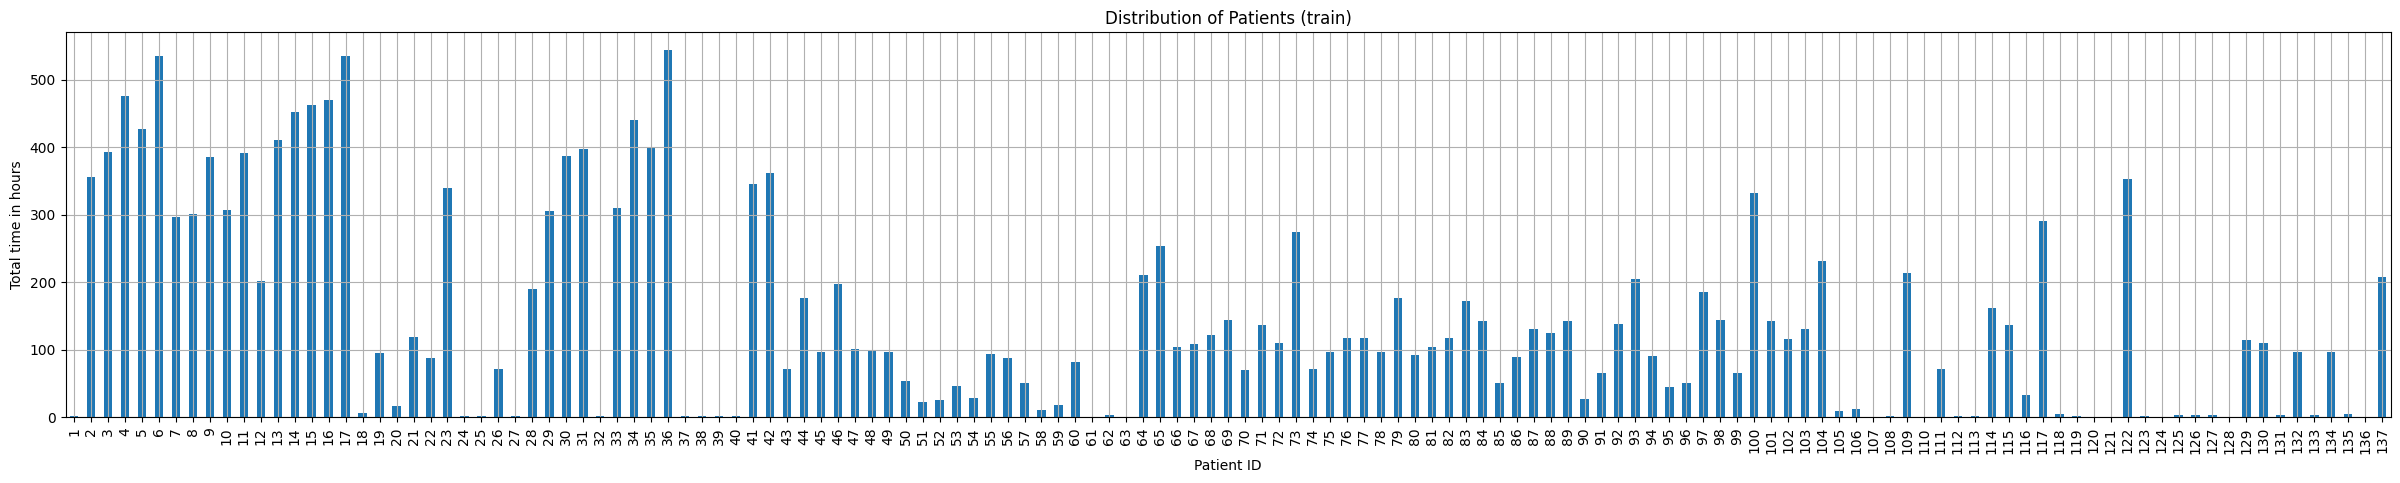

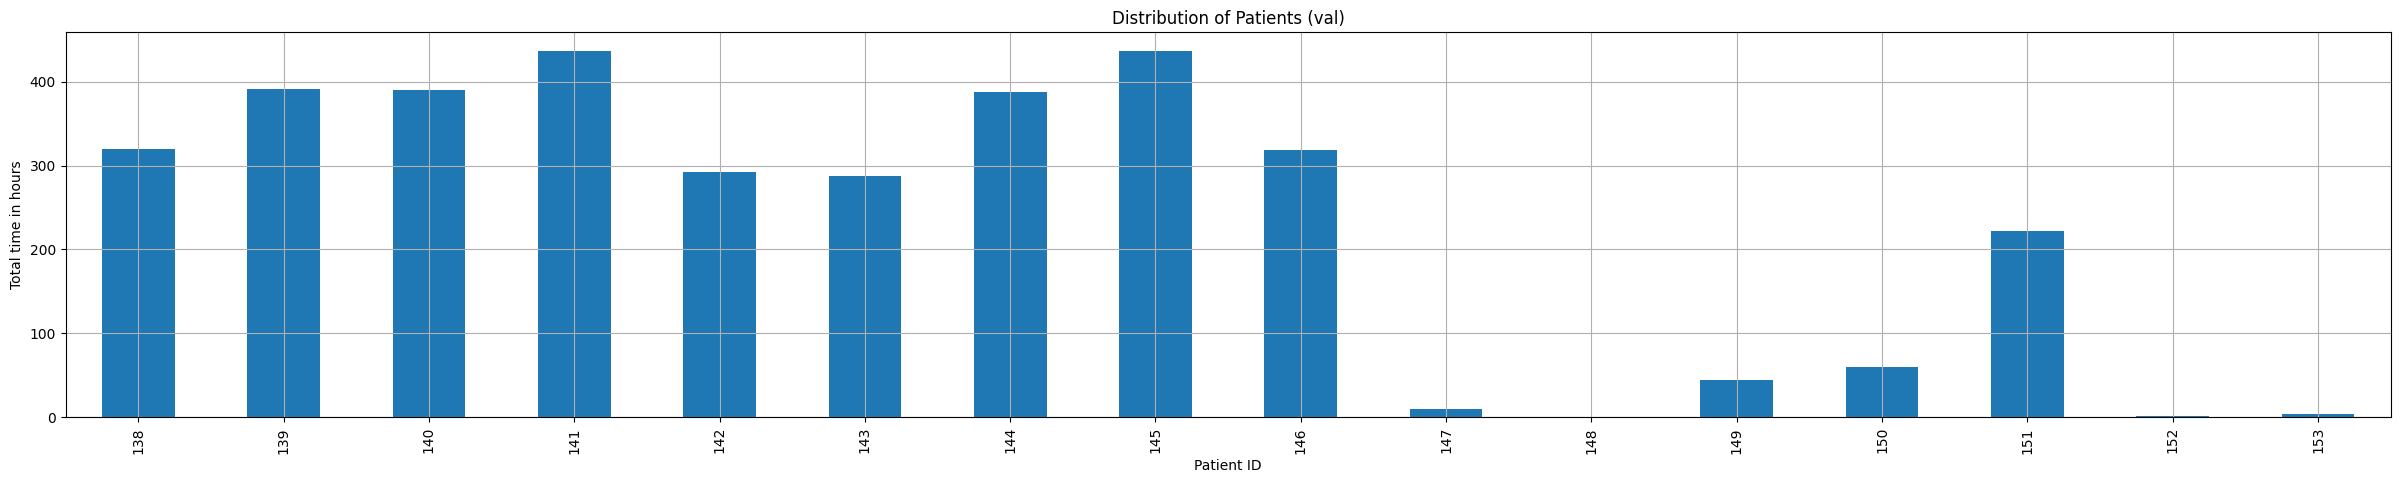

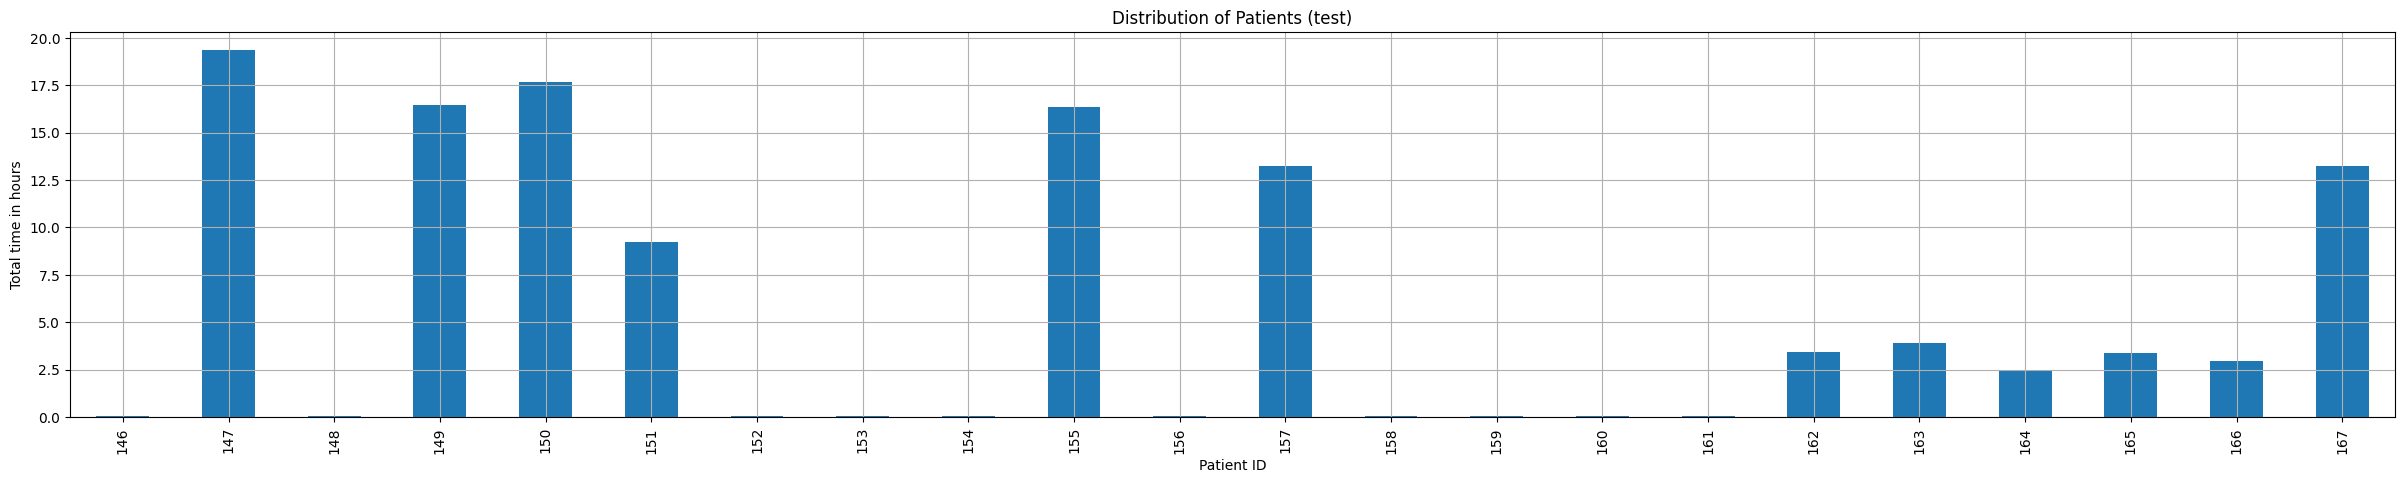

2
146       4.583333
147    1160.000000
148       4.583333
149     986.666667
150    1060.000000
151     553.333333
152       4.166667
153       3.333333
154       4.583333
155     980.000000
156       5.000000
157     795.000000
158       3.333333
159       5.000000
160       4.583333
161       3.750000
162     206.666667
163     233.333333
164     146.666667
165     204.166667
166     178.333333
167     793.333333
Name: count, dtype: float64
Average time in hours for train: 142.12966342254663
Average time in hours for val: 225.16579861111111
Average time in hours for test: 5.560921717171717


In [9]:
count_patients = sample_train_df[2].value_counts()
count_patients_val = sample_val_df[2].value_counts()
count_patients_test = sample_test_df[2].value_counts()
# order by index
count_patients = count_patients.sort_index() * 25 / 3600
count_patients_val = count_patients_val.sort_index() * 25 / 3600
count_patients_test = count_patients_test.sort_index() * 25 / 3600

# plot the distribution of patients
import matplotlib.pyplot as plt
plt.figure(figsize=(30, 5))
count_patients.plot(kind='bar')
plt.title('Distribution of Patients (train)')
plt.xlabel('Patient ID')
plt.ylabel('Total time in hours')
plt.grid()
plt.show()

plt.figure(figsize=(30, 5))
count_patients_val.plot(kind='bar')
plt.title('Distribution of Patients (val)')
plt.xlabel('Patient ID')
plt.ylabel('Total time in hours')
plt.grid()
plt.show()

plt.figure(figsize=(30, 5))
count_patients_test.plot(kind='bar')
plt.title('Distribution of Patients (test)')
plt.xlabel('Patient ID')
plt.ylabel('Total time in hours')
plt.grid()
plt.show()

# print the smaller values of the test
print(count_patients_test * 60)
# print the average
print(f'Average time in hours for train: {count_patients.mean()}')
print(f'Average time in hours for val: {count_patients_val.mean()}')
print(f'Average time in hours for test: {count_patients_test.mean()}')


Index of patient 147 in test set: [4823, 4824, 4825, 4826, 4827, 4828, 4829, 4830, 4831, 4832, 4833, 4834, 4835, 4836, 4837, 4838, 4839, 4840, 4841, 4842, 4843, 4844, 4845, 4846, 4847, 4848, 4849, 4850, 4851, 4852, 4853, 4854, 4855, 4856, 4857, 4858, 4859, 4860, 4861, 4862, 4863, 4864, 4865, 4866, 4867, 4868, 4869, 4870, 4871, 4872, 4873, 4874, 4875, 4876, 4877, 4878, 4879, 4880, 4881, 4882, 4883, 4884, 4885, 4886, 4887, 4888, 4889, 4890, 4891, 4892, 4893, 4894, 4895, 4896, 4897, 4898, 4899, 4900, 4901, 4902, 4903, 4904, 4905, 4906, 4907, 4908, 4909, 4910, 4911, 4912, 4913, 4914, 4915, 4916, 4917, 4918, 4919, 4920, 4921, 4922, 4923, 4924, 4925, 4926, 4927, 4928, 4929, 4930, 4931, 4932, 4933, 4934, 4935, 4936, 4937, 4938, 4939, 4940, 4941, 4942, 4943, 4944, 4945, 4946, 4947, 4948, 4949, 4950, 4951, 4952, 4953, 4954, 4955, 4956, 4957, 4958, 4959, 4960, 4961, 4962, 4963, 4964, 4965, 4966, 4967, 4968, 4969, 4970, 4971, 4972, 4973, 4974, 4975, 4976, 4977, 4978, 4979, 4980, 4981, 4982, 4983,

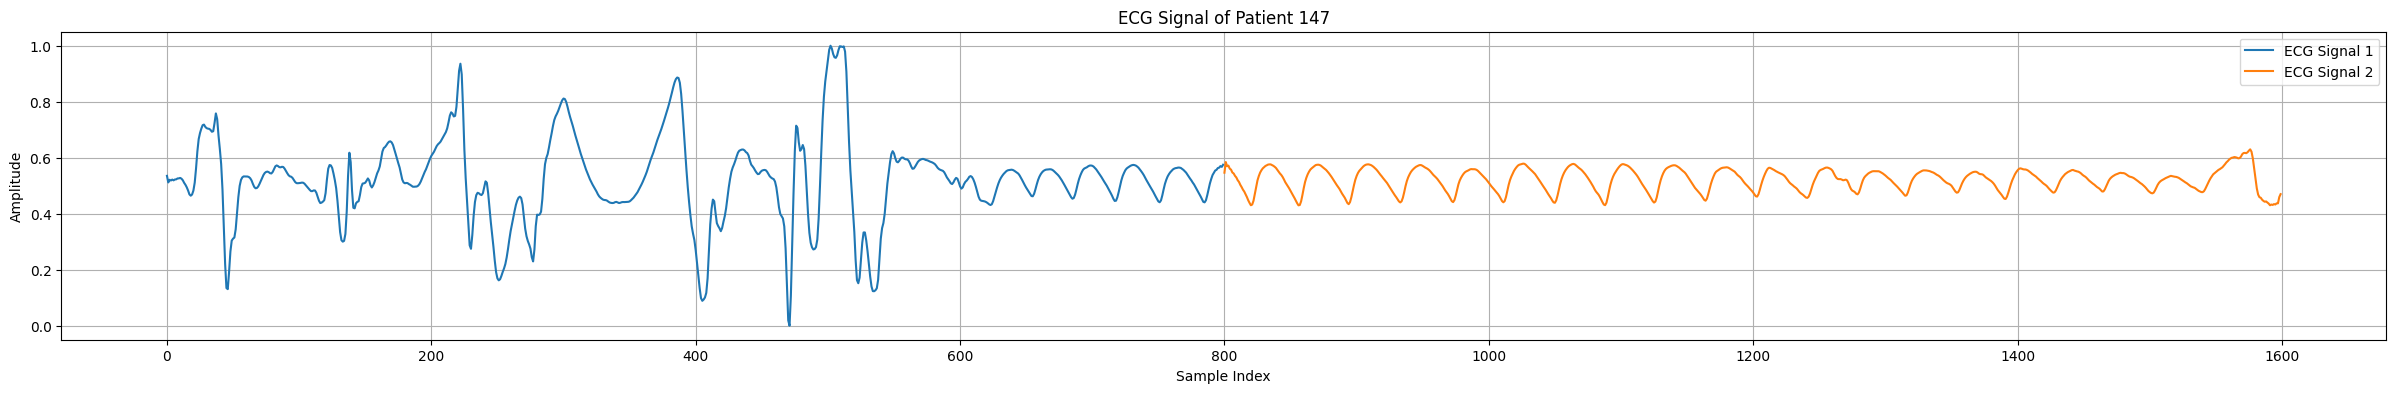

In [10]:
# get the index where patient is 147
index_147 = sample_test_df[sample_test_df[2] == 147].index
print(f'Index of patient 147 in test set: {index_147.to_list()}')

idx = 8
test_sample_1 = sample_test['signal'][index_147[idx]]
test_sample_2 = sample_test['signal'][index_147[idx + 1]] * 0.2 + 0.43

# plot the signal
import matplotlib.pyplot as plt
plt.figure(figsize=(30, 4))
plt.plot(test_sample_1, label='ECG Signal 1')
plt.plot(np.arange(len(test_sample_1), len(test_sample_1) + len(test_sample_2)), test_sample_2, label='ECG Signal 2')
plt.legend()
plt.title('ECG Signal of Patient 147')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid()

In [64]:
# print one sample
dataset = ECGCODE15Dataset(config, global_augmentations=get_transforms(config, split='train', type='global'), local_augmentations=get_transforms(config, split='train', type='local'))



using leads : ['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']
tabular data fields for CODE 15:           Unnamed: 0.1  Unnamed: 0  age  is_male  nn_predicted_age  1dAVb  \
exam_id                                                                    
1169160             0           0   38     True         40.160484  False   
2873686             1           1   73     True         67.059440  False   
168405              2           2   67     True         79.621740  False   
271011              3           3   41     True         69.750260  False   
384368              4           4   73     True         78.873460  False   

          RBBB   LBBB     SB     ST     AF  patient_id  death     timey  \
exam_id                                                                   
1169160  False  False  False  False  False      523632  False  2.098628   
2873686  False  False  False  False  False     1724173  False  6.657529   
168405   False  False  False  False   True 

Sample keys: dict_keys(['global_signals', 'local_signals'])
Global view 1 shape: torch.Size([921, 12])


/tmp/ipykernel_758458/1598727430.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=g1[:, 1], palette="tab10", legend=False)


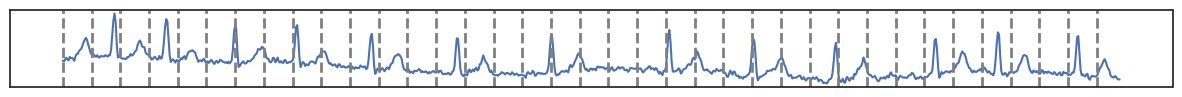

In [88]:
sample = dataset[9]
print("Sample keys:", sample.keys())
g1 = sample['global_signals'][0]
print("Global view 1 shape:", g1.shape)

# plot in a box with seaborn

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 1))
plt.tight_layout()
sns.lineplot(data=g1[:, 1], palette="tab10", legend=False)
# at every 25 timestep wrap in a box with sns
for i in range(0, g1.shape[0], 25):
    plt.axvline(x=i, color='gray', linestyle='--', linewidth=2)

plt.xticks([])
plt.yticks([])
#export to png
plt.savefig('figs/sample_global_view_1.png', bbox_inches='tight', dpi=300)

In [118]:
from dataset import generic_utils
import dataset.cpsc2018 as cpsc_utils

train_dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=config.num_workers, collate_fn=generic_utils.make_collate_fn(config), drop_last=True)
sample = train_dataloader.__iter__().__next__()
print(sample.keys())

dict_keys(['global_signals', 'local_signals'])


Global view 1 shape: torch.Size([4, 925, 12])
Global view 2 shape: torch.Size([4, 900, 12])


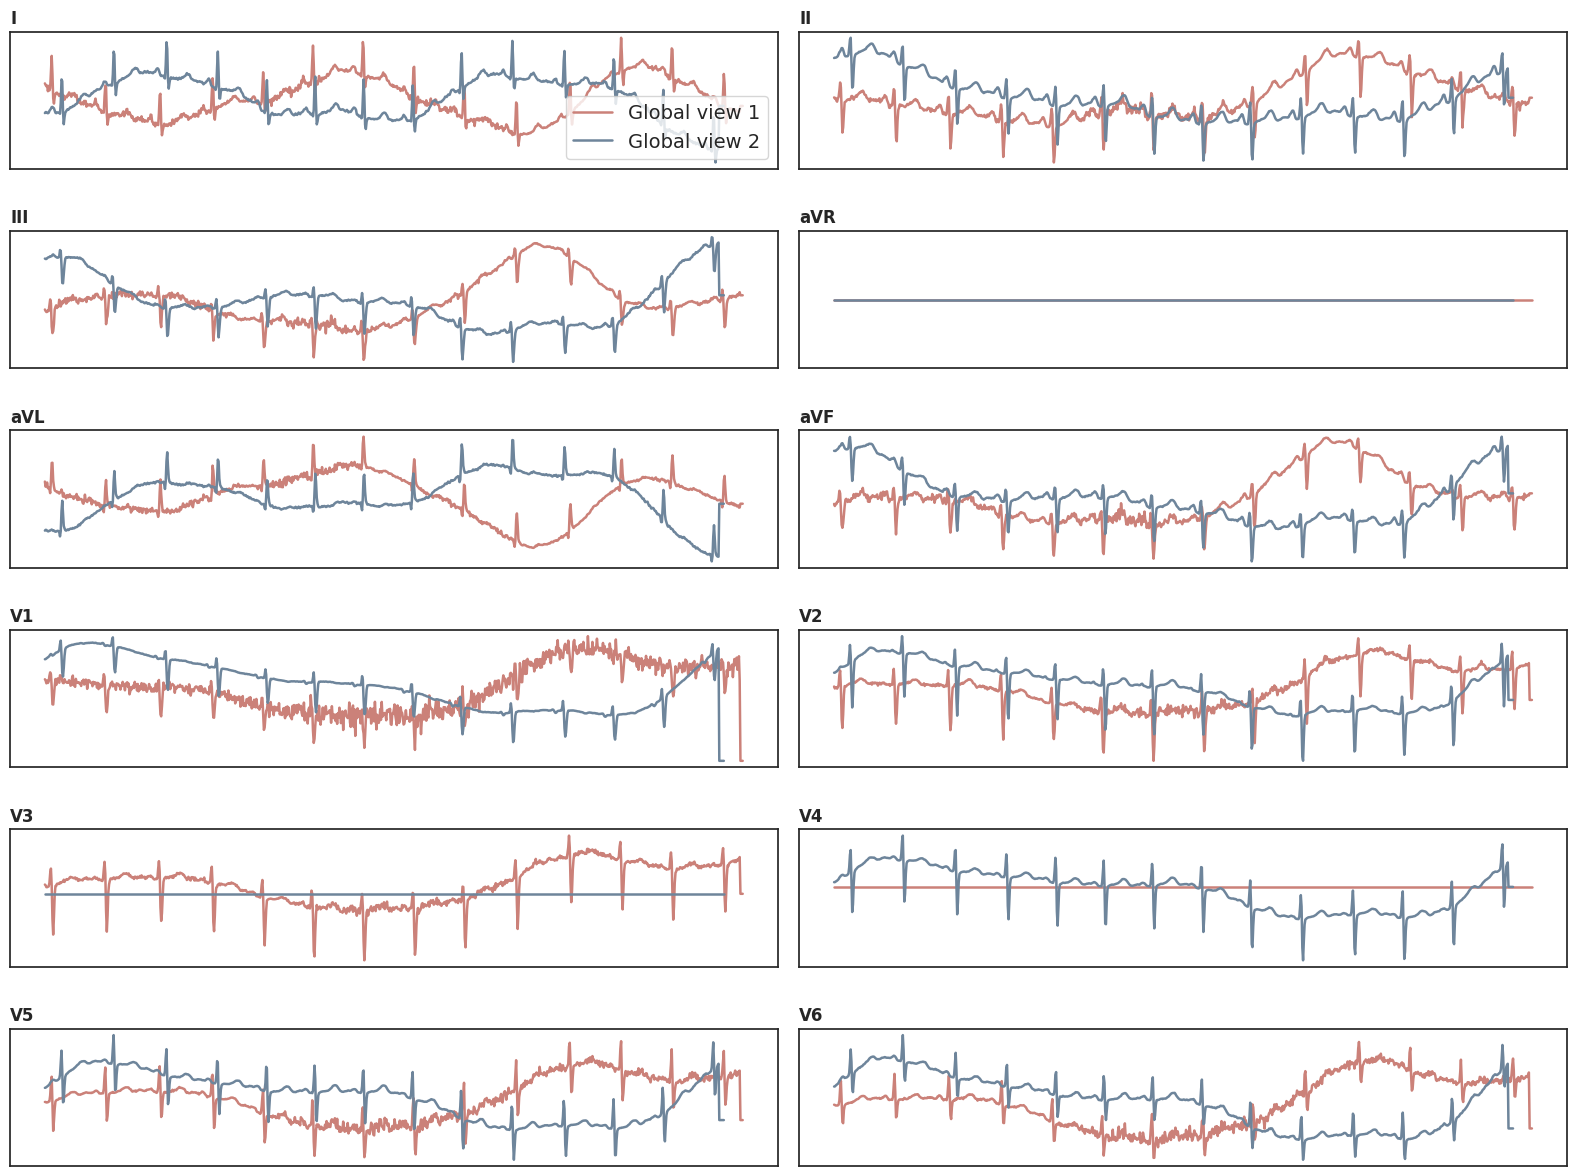

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use a modern Seaborn style
sns.set(style="white", context="notebook", font_scale=1.2)

# Your list of ECG leads
leads = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

# Create subplot grid: 6 rows x 2 columns
fig, axs = plt.subplots(6, 2, figsize=(16, 12))  # Adjust size for clarity

# Flatten axes array for easy indexing
axs = axs.flatten()

# Define colors
color_g1 = '#cb8179'  # warm tone
color_g2 = '#6e859b'  # cool tone

sample_g1 = sample['global_signals'][0] # Global view 1
sample_g2 = sample['global_signals'][1]  # Global view 2
print("Global view 1 shape:", sample_g1.shape)
print("Global view 2 shape:", sample_g2.shape)

# Loop over the 12 leads
for i in range(12):
    ax = axs[i]
    ax.plot(sample_g1[0, :, i], color=color_g1, label='Global view 1', linewidth=1.8)
    ax.plot(sample_g2[0, :, i], color=color_g2, label='Global view 2', linewidth=1.8)

    # Title
    ax.set_title(leads[i], fontsize=12, weight='bold', loc='left')

    # Remove ticks for a clean look
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove spines for minimalist style
    # for spine in ax.spines.values():
    #    spine.set_visible(False)

    # Add legend only once
    if i == 0:
        ax.legend(frameon=True, fontsize=14)

# Turn off unused subplot if needed (in case you have more than 12 axes)
for j in range(12, len(axs)):
    fig.delaxes(axs[j])

# Tight layout for cleaner spacing
plt.tight_layout(h_pad=2)

# Optional: add a global title
# fig.suptitle("ECG Lead Comparison — Global Views", fontsize=16, weight='bold', y=1.02)

plt.savefig('figs/ecg_lead_comparison_global_views.png', bbox_inches='tight', dpi=300)
plt.show()

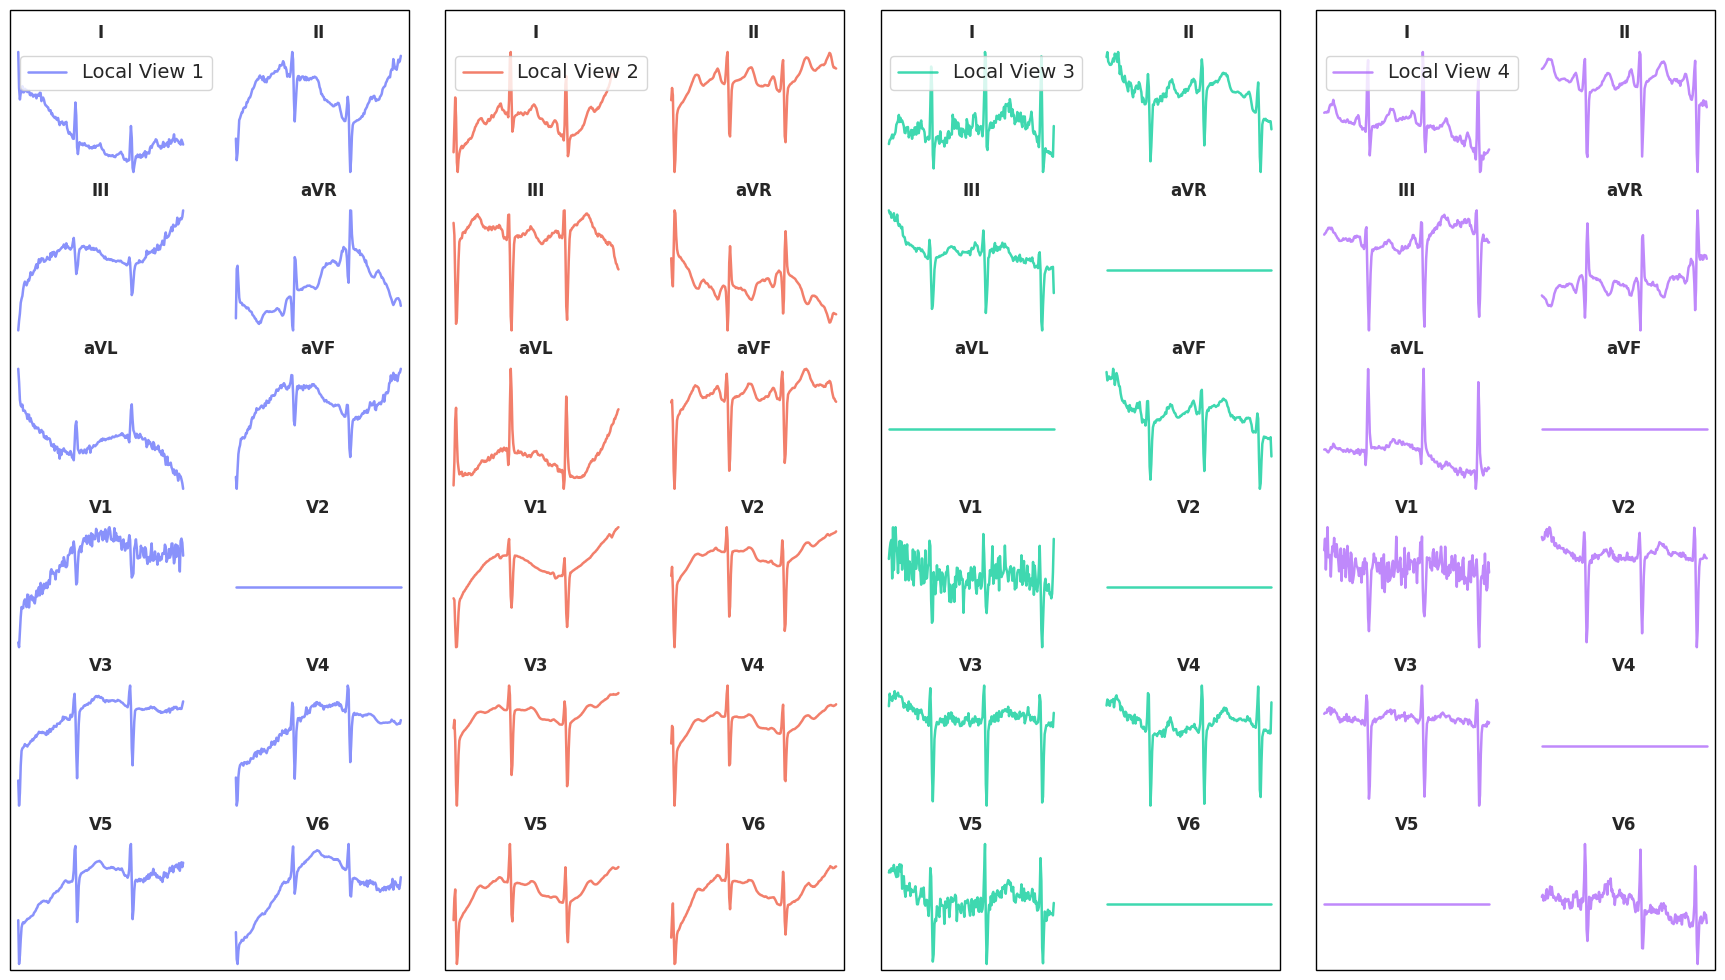

In [127]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
from plotly.colors import qualitative

n_groups = 4
# --- Existing setup ---
fig, axs = plt.subplots(6, n_groups * 2, figsize=(22, 12))
axs = np.array(axs)
sample_idx = 0  # Index of the sample to plot
colors = qualitative.Plotly[:len(sample['local_signals'])]
colors = [f"{color}c0" for color in colors]  #
# Plotting signals
for j, g in enumerate(sample['local_signals']):
    for i in range(12):
        row = i // 2
        col = (i % 2) + j * 2
        ax = axs[row, col]
        ax.plot(g[sample_idx, :, i], color=colors[j], linewidth=1.8)

        # if row == 0:
        ax.set_title(leads[i], fontsize=12, weight='bold')

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        # add legend only to the first column of each group
        if i == 0:
            ax.legend(
                [f'Local View {j+1}'],
                loc='upper left',
                fontsize=14,
                frameon=True,
                title_fontsize='12'
            )

# --- Fix rectangle positions ---
fig.canvas.draw()  # Important to get updated positions

for j in range(n_groups):
    ax_topleft = axs[0, j*2]
    ax_bottomright = axs[5, j*2+1]

    bbox1 = ax_topleft.get_position()
    bbox2 = ax_bottomright.get_position()

    # Slightly expand the rectangle bounds for better fit
    x0 = bbox1.x0
    y1 = bbox1.y1 + 0.03
    x1 = bbox2.x1 
    y0 = bbox2.y0 

    # Add background or border
    rect = Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        transform=fig.transFigure,
        fill=False,  # change to True and add alpha for shading
        color='black',
        linewidth=1,
        zorder=1000  # ensure it's on top
    )
    fig.patches.append(rect)

    # Add title above group
    # fig.text(
    #    (x0 + x1) / 2, y1 + 0.01,
    #    f'Local View {j+1}',
    #    fontsize=12,
    #    ha='center',
    #    weight='bold'
    #)# 

# --- Layout ---
# plt.tight_layout(h_pad=1.5, w_pad=0.5)
# fig.suptitle("Local Signal Comparison Across Leads", fontsize=16, weight='bold', y=1.03)
plt.savefig('figs/local_signal_comparison_across_leads.png', bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
import yaml
from dataset.generic_utils import get_transforms

from dataset.mit_bih import ECGMITBIHDataset
from utils.utils import parse_config

cfg = parse_config('configs/train_mit_bih_run_config.yaml', 'config_defaults/train_mit_bih_config_defaults.yaml')

dataset = ECGMITBIHDataset(cfg, split='val', augmentations=get_transforms(cfg, type='global', split='val'))

/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


freq_factor: 1.3888888888888888, sampling_freq: 500, original_freq: 360


In [ ]:
sample = dataset[0]
print(sample.keys())
print(sample['r_peaks'])

import matplotlib.pyplot as plt

# plot the signal
plt.figure(figsize=(25, 5))
leads = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

def get_color(i):
    if i == 0:
        return 'red'
    elif i == 1:
        return 'blue'
    elif i == 2:
        return 'green'
    elif i == 3:
        return 'orange'
    elif i == 4:
        return 'purple'
    elif i == 5:
        return 'pink'
    else:
        return 'grey'
    
label = sample['label'].unsqueeze(0).unfold(1, cfg.patch_size, cfg.patch_size).max(dim=-1)[0].long().squeeze()
print(label.shape)
print(sample['signal'].shape)
    
plt.plot(sample['signal'][:, 1])

for j in range(0, len(sample['r_peaks']), cfg.patch_size):
    if sample['r_peaks'][j] != -1 and j // cfg.patch_size < len(label):
        # color the area between the r_peaks
        plt.axvspan(j, j+cfg.patch_size, color=get_color(label[j // cfg.patch_size]), alpha=0.2)


plt.show()

dict_keys(['signal', 'patient_id', 'r_peak', 'r_peak_orig'])


KeyError: 'r_peaks'

In [ ]:
from dataset.cpsc2018 import ECGCPSC2018Dataset
from utils.utils import parse_config
from dataset.generic_utils import get_transforms


cfg = parse_config('configs/train_cpsc2018_run_config.yaml', 'config_defaults/train_cpsc2018_defaults.yaml')

dataset = ECGCPSC2018Dataset(cfg, split='test', global_augmentations=get_transforms(cfg, type='global', split='val'))

sample path CODE15: g7/A6001
loaded 877 records
loaded 9 labels
labels: ['284470004', '59118001', '270492004', '164884008', '426783006', '164931005', '164889003', '164909002', '429622005']


In [ ]:
label = sample['label'].unsqueeze(0).unfold(1, config.patch_size, config.patch_size).max(dim=-1)[0].long()
print(label.shape)
print(sample['label'].shape)
print(label)

torch.Size([1, 225])
torch.Size([7200])
tensor([[ 0,  0, -1,  0,  0, -1,  0, -1,  0, -1,  0, -1,  2, -1,  0, -1,  0,  0,
          0, -1, -1,  0, -1,  0,  2, -1, -1,  0,  0, -1,  0, -1,  0, -1,  0,  0,
         -1,  0,  0, -1,  0,  0,  0, -1,  0,  0, -1,  0,  2,  0, -1, -1,  0,  0,
         -1,  0,  0, -1,  0,  2, -1,  0,  0, -1, -1,  0, -1,  0,  0,  0, -1,  0,
         -1, -1,  0, -1,  2, -1,  0, -1,  0,  2,  2,  2, -1,  0, -1,  0, -1, -1,
          0,  0, -1,  0,  2, -1, -1,  0,  2, -1,  0, -1,  2,  2,  0, -1,  0,  2,
         -1,  0,  2, -1, -1,  0, -1,  0,  0, -1,  0,  0, -1,  0,  0, -1,  0, -1,
          0, -1,  0,  0, -1,  0,  0, -1,  0, -1, -1,  0,  2,  2,  0, -1,  0,  0,
         -1,  0, -1,  0, -1,  0, -1,  0, -1, -1,  0,  2, -1,  0, -1,  0, -1,  0,
          0, -1,  0,  0,  0,  0, -1, -1,  0, -1,  0, -1,  0, -1,  0, -1,  0,  2,
          2,  2,  2, -1,  0,  2, -1, -1,  0,  0, -1, -1,  0,  0, -1, -1,  0, -1,
          0,  2,  2,  0, -1,  0, -1,  0,  0, -1,  0, -1,  0, -1,  0, 

In [ ]:
import yaml
from dataset.generic_utils import get_transforms

from dataset.sleep_apnea import ECGSleepApneaDataset
from utils.utils import parse_config

cfg = parse_config('configs/train_sleep_apnea_run_config.yaml', 'config_defaults/train_sleep_apnea_defaults.yaml')

dataset = ECGSleepApneaDataset(cfg, split='train')

Loading samples: 100%|██████████| 31/31 [00:00<00:00, 125.47it/s]

ann shape: torch.Size([1660]) should match 1660.0
ann shape: torch.Size([280]) should match 280.0
ann shape: torch.Size([1680]) should match 1680.0
ann shape: torch.Size([120]) should match 120.0
ann shape: torch.Size([800]) should match 800.0
ann shape: torch.Size([280]) should match 280.0
ann shape: torch.Size([320]) should match 320.0
ann shape: torch.Size([540]) should match 540.0
ann shape: torch.Size([980]) should match 980.0
ann shape: torch.Size([1200]) should match 1200.0
ann shape: torch.Size([2320]) should match 2320.0
ann shape: torch.Size([720]) should match 720.0
ann shape: torch.Size([1960]) should match 1960.0
ann shape: torch.Size([1920]) should match 1920.0
ann shape: torch.Size([1760]) should match 1760.0
ann shape: torch.Size([2240]) should match 2240.0
ann shape: torch.Size([100]) should match 100.0
ann shape: torch.Size([2160]) should match 2160.0
ann shape: torch.Size([1440]) should match 1440.0
ann shape: torch.Size([2160]) should match 2160.0
ann shape: torch.S

In [ ]:
sample = dataset[0]
print(sample.keys())
print(sample['annotation'].shape)
print(sample['signal'].shape[0] / 25)


dict_keys(['signal', 'annotation'])
torch.Size([103920])
2400.0


In [ ]:
dataset_mit_test = ECGMITBIHDataset(DatasetArgs(), subset='test')
print('dataset_mit_test len:', len(dataset_mit_test))

dataset_val = ECGMITBIHDataset(DatasetArgs(), subset='val', random_shift=False)
print('dataset_mit_val len:', len(dataset_val))

dataset_mit = ECGMITBIHDataset(DatasetArgs(), random_shift=False)
print('dataset_mit len:', len(dataset_mit))

Processing patients: 100%|██████████| 22/22 [00:00<00:00, 44924.39it/s]


dataset_mit_test len: 1342


Processing patients: 100%|██████████| 2/2 [00:00<00:00, 4629.47it/s]

dataset_mit_val len: 122



Processing patients: 100%|██████████| 20/20 [00:00<00:00, 50870.88it/s]


dataset_mit len: 10552


In [ ]:
from dataset.mit_bih import collate_fn

train_dataloader = DataLoader(dataset_mit, batch_size=128, shuffle=True, num_workers=32, collate_fn=collate_fn)
val_dataloader = DataLoader(dataset_val, batch_size=128, shuffle=False, num_workers=32, collate_fn=collate_fn)
test_dataloader = DataLoader(dataset_mit_test, batch_size=128, shuffle=False, num_workers=32, collate_fn=collate_fn)

# sanity check  
batch_train = next(iter(train_dataloader))  
print('batch_train len:', len(batch_train))
print('batch_train keys:', batch_train.keys())

batch_val = next(iter(val_dataloader))
print('batch_val len:', len(batch_val))
print('batch_val keys:', batch_val.keys())

batch_test = next(iter(test_dataloader))
print('batch_test len:', len(batch_test))
print('batch_test keys:', batch_test.keys())

batch_train len: 5
batch_train keys: dict_keys(['signal', 'label', 'patient_ids', 'r_peak', 'labels'])
batch_val len: 5
batch_val keys: dict_keys(['signal', 'label', 'patient_ids', 'r_peak', 'labels'])
batch_test len: 5
batch_test keys: dict_keys(['signal', 'label', 'patient_ids', 'r_peak', 'labels'])


In [ ]:
import torch

def banded_tril_mask_indices(length: int, n: int) -> torch.Tensor:
    """
    Generates a len x len boolean mask where elements (row, col) are True
    iff row >= col AND row - col < n. This creates a lower triangular
    band starting from the main diagonal with width n.

    Args:
        length: The total size of the square matrix (len x len).
        n: The width of the band (number of diagonals including the main one).
           n=1 gives the main diagonal, n=2 gives main and first sub-diagonal, etc.

    Returns:
        A torch.Tensor of shape (length, length) and dtype torch.bool.
    """
    if not isinstance(length, int) or length <= 0:
        raise ValueError("length must be a positive integer")
    if not isinstance(n, int) or n <= 0:
        # n=0 would result in an all-False matrix, handled implicitly,
        # but usually n>=1 is intended for this pattern.
        raise ValueError("n (band width) must be a positive integer")

    # Create row and column indices
    rows = torch.arange(length).unsqueeze(1) # Shape: (length, 1)
    cols = torch.arange(length).unsqueeze(0) # Shape: (1, length)

    # Broadcasting creates (length, length) comparison tensors
    on_or_below_diag = rows >= cols
    within_band = (rows - cols) < n  # Difference is 0, 1, ..., n-1

    # Combine conditions using logical AND
    mask = on_or_below_diag & within_band

    return mask

# Example Usage
length = 5
n = 3 # Main diagonal (0), 1st sub-diag (1), 2nd sub-diag (2)
mask1 = banded_tril_mask_indices(length, n)
print("Method 1 (Indices):")
print(mask1)
# Expected Output:
# tensor([[ True, False, False, False, False],
#         [ True,  True, False, False, False],
#         [ True,  True,  True, False, False],
#         [False,  True,  True,  True, False],
#         [False, False,  True,  True,  True]])

length = 6
n = 4
mask1_large = banded_tril_mask_indices(length, n)
print("\nMethod 1 (Indices) - Larger Example (n=4):")
print(mask1_large)
# Expected Output:
# tensor([[ True, False, False, False, False, False],
#         [ True,  True, False, False, False, False],
#         [ True,  True,  True, False, False, False],
#         [ True,  True,  True,  True, False, False],
#         [False,  True,  True,  True,  True, False],
#         [False, False,  True,  True,  True,  True]])

Method 1 (Indices):
tensor([[ True, False, False, False, False],
        [ True,  True, False, False, False],
        [ True,  True,  True, False, False],
        [False,  True,  True,  True, False],
        [False, False,  True,  True,  True]])

Method 1 (Indices) - Larger Example (n=4):
tensor([[ True, False, False, False, False, False],
        [ True,  True, False, False, False, False],
        [ True,  True,  True, False, False, False],
        [ True,  True,  True,  True, False, False],
        [False,  True,  True,  True,  True, False],
        [False, False,  True,  True,  True,  True]])


In [ ]:
import torch

def banded_tril_mask_indices(length: int, n: int) -> torch.Tensor:
    """
    Generates the banded lower triangular mask from the previous step.
    Elements (row, col) are True iff row >= col AND row - col < n.
    """
    if not isinstance(length, int) or length <= 0:
        raise ValueError("length must be a positive integer")
    if not isinstance(n, int) or n <= 0:
        raise ValueError("n (band width) must be a positive integer")
    rows = torch.arange(length).unsqueeze(1)
    cols = torch.arange(length).unsqueeze(0)
    on_or_below_diag = rows >= cols
    within_band = (rows - cols) < n
    return on_or_below_diag & within_band

def keep_first_true_per_row(input_mask: torch.Tensor) -> torch.Tensor:
    """
    Creates a new mask where only the first 'True' element in each row
    of the input_mask is set to 'True'. If a row has no 'True' elements,
    the corresponding output row will be all 'False'.

    Args:
        input_mask: The input boolean tensor (2D).

    Returns:
        A new boolean tensor with only the first True per row preserved.
    """
    if input_mask.dim() != 2:
        raise ValueError("Input mask must be 2D")

    # Find the index of the first True (max value = 1) in each row.
    # Use .int() or .float() as argmax works on numerical types.
    # Note: argmax returns 0 for rows that are all False.
    first_true_indices = torch.argmax(input_mask.int(), dim=1)

    # Create an output mask initialized to False
    output_mask = torch.zeros_like(input_mask, dtype=torch.bool)

    # Identify rows that actually contain at least one True
    # This is crucial to handle rows that were all False in the input
    rows_with_true = torch.any(input_mask, dim=1)

    # Get the row indices where we need to set a True value
    valid_row_indices = torch.where(rows_with_true)[0]

    # If there are no rows with True at all, return the all-False mask
    if len(valid_row_indices) == 0:
        return output_mask

    # Select the corresponding first_true_indices ONLY for these valid rows
    valid_first_true_indices = first_true_indices[valid_row_indices]

    # Use advanced indexing to set only the first True element in valid rows
    output_mask[valid_row_indices, valid_first_true_indices] = True

    return output_mask

# --- Generate the starting mask (banded lower triangular) ---
length = 6
n_band = 3
original_mask = banded_tril_mask_indices(length, n_band)

print("Original Banded Mask:")
print(original_mask)
# Expected:
# tensor([[ True, False, False, False, False],
#         [ True,  True, False, False, False],
#         [ True,  True,  True, False, False],
#         [False,  True,  True,  True, False],
#         [False, False,  True,  True,  True]])

# --- Apply the rule to keep only the first True per row ---
final_mask = keep_first_true_per_row(original_mask)

print("\nFinal Mask (First True per Row):")
print(final_mask)


Original Banded Mask:
tensor([[ True, False, False, False, False, False],
        [ True,  True, False, False, False, False],
        [ True,  True,  True, False, False, False],
        [False,  True,  True,  True, False, False],
        [False, False,  True,  True,  True, False],
        [False, False, False,  True,  True,  True]])

Final Mask (First True per Row):
tensor([[ True, False, False, False, False, False],
        [ True, False, False, False, False, False],
        [ True, False, False, False, False, False],
        [False,  True, False, False, False, False],
        [False, False,  True, False, False, False],
        [False, False, False,  True, False, False]])


In [ ]:
import torch

bs, seq_len, emb_size = 2, 5, 3  # for instance

x = torch.arange(bs * seq_len * emb_size).reshape(bs, seq_len, emb_size)
print('x:', x)

loopback = 4
causal_mask = banded_tril_mask_indices(seq_len, loopback)  # shape [seq_len, seq_len]
causal_idx = keep_first_true_per_row(causal_mask)  # shape [seq_len, seq_len]
print('causal_idx:', causal_idx)
print('causal_mask:', causal_mask)

causal_mask = causal_mask.unsqueeze(0).unsqueeze(-1)  # now shape [1, seq_len, seq_len, 1]
x_expanded = x.unsqueeze(1).expand(bs, seq_len, seq_len, emb_size)
# print('x_expanded:', x_expanded)

x_causal = x_expanded.masked_fill(~causal_mask, 0)
print('x_causal:', x_causal)
x_causal = x_causal.reshape(bs * seq_len, seq_len, emb_size)
# x_causal = x_causal.flip(1)
print('x_causal flipped:', x_causal)
x = x_causal.reshape(bs, seq_len, seq_len, emb_size)
x = x[:, causal_idx, :]

print('x:', x)

x: tensor([[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11],
         [12, 13, 14]],

        [[15, 16, 17],
         [18, 19, 20],
         [21, 22, 23],
         [24, 25, 26],
         [27, 28, 29]]])
causal_idx: tensor([[ True, False, False, False, False],
        [ True, False, False, False, False],
        [ True, False, False, False, False],
        [ True, False, False, False, False],
        [False,  True, False, False, False]])
causal_mask: tensor([[ True, False, False, False, False],
        [ True,  True, False, False, False],
        [ True,  True,  True, False, False],
        [ True,  True,  True,  True, False],
        [False,  True,  True,  True,  True]])
x_causal: tensor([[[[ 0,  1,  2],
          [ 0,  0,  0],
          [ 0,  0,  0],
          [ 0,  0,  0],
          [ 0,  0,  0]],

         [[ 0,  1,  2],
          [ 3,  4,  5],
          [ 0,  0,  0],
          [ 0,  0,  0],
          [ 0,  0,  0]],

         [[ 0,  1,  2],
        

In [ ]:
from matplotlib.widgets import Slider
from ipywidgets import interact

pat_id = dataset_mit.patients[-2]
print('pat_id:', pat_id)
# pat_id = 202
patient = dataset_mit.signals[pat_id][:, 0]
header = dataset_mit.headers[pat_id]
annotations = dataset_mit.annotations[pat_id]
# print(annotations.__dict__)

def convert_label(symbol):
    """
    Convert the symbols to the main class label
    """
    if symbol in ['N', 'L', 'R', 'e', 'j']:
        return 'N'
    elif symbol in ['A', 'a', 'J', 'S']:
        return 'S'  # Supraventricular ectopic
    elif symbol in ['V', 'E']:
        return 'V'  # Ventricular ectopic
    elif symbol in ['F']:
        return 'F'  # Fusion
    elif symbol in ['/', 'f', 'Q']:
        return 'Q'  # Unknown
    else:
        print(symbol)
        raise (f'Unknown symbol {symbol}')
    
def int_to_label(val):
    if val == 0:
        return 'N'
    elif val == 1:
        return 'S'
    elif val == 2:
        return 'V'
    elif val == 3:
        return 'F'
    elif val == 4:
        return 'Q'
    else:
        raise (f'Unknown label {val}')
    
valid_annotations = set(['N', 'L', 'R', 'e', 'j', 'A', 'a', 'J', 'S', 'V', 'E', 'F', '/', 'f', 'Q'])

r_peaks = annotations.sample
r_peaks = [r_peak for i, r_peak in enumerate(r_peaks) if annotations.symbol[i] in valid_annotations]

labels_orig = [label for label in annotations.symbol if label in valid_annotations]
labels = [convert_label(l) for l in labels_orig]


import matplotlib.pyplot as plt

def plot_scrollable(start):
    end = start + 10000
    plt.figure(figsize=(30, 4))
    plt.plot(patient)
    plt.xlim(start, end)
    
    # Convert x-axis ticks to seconds
    #plt.xticks(
    #    ticks=range(start, end, 3600),  # 360 samples per second, so 3600 for 10-second intervals
    #    labels=[f"{x/360:.1f}s" for x in range(start, end, 3600)]
    #)
    
    # Add labels at r_peak positions
    for r_peak, label, orig in zip(r_peaks, labels, labels_orig):
        if start <= r_peak < end:
            plt.text(r_peak, patient[r_peak], label, color='red', fontsize=12, ha='center', va='bottom')
            plt.text(r_peak, patient[r_peak], orig, color='blue', fontsize=12, ha='center', va='top')
    plt.show()

interact(plot_scrollable, start=(0, len(patient) - 1000, 8000))


pat_id: 223


interactive(children=(IntSlider(value=320000, description='start', max=649000, step=8000), Output()), _dom_cla…

<function __main__.plot_scrollable(start)>

10552
r_peaks shape: torch.Size([9360])
labels shape: torch.Size([9360])


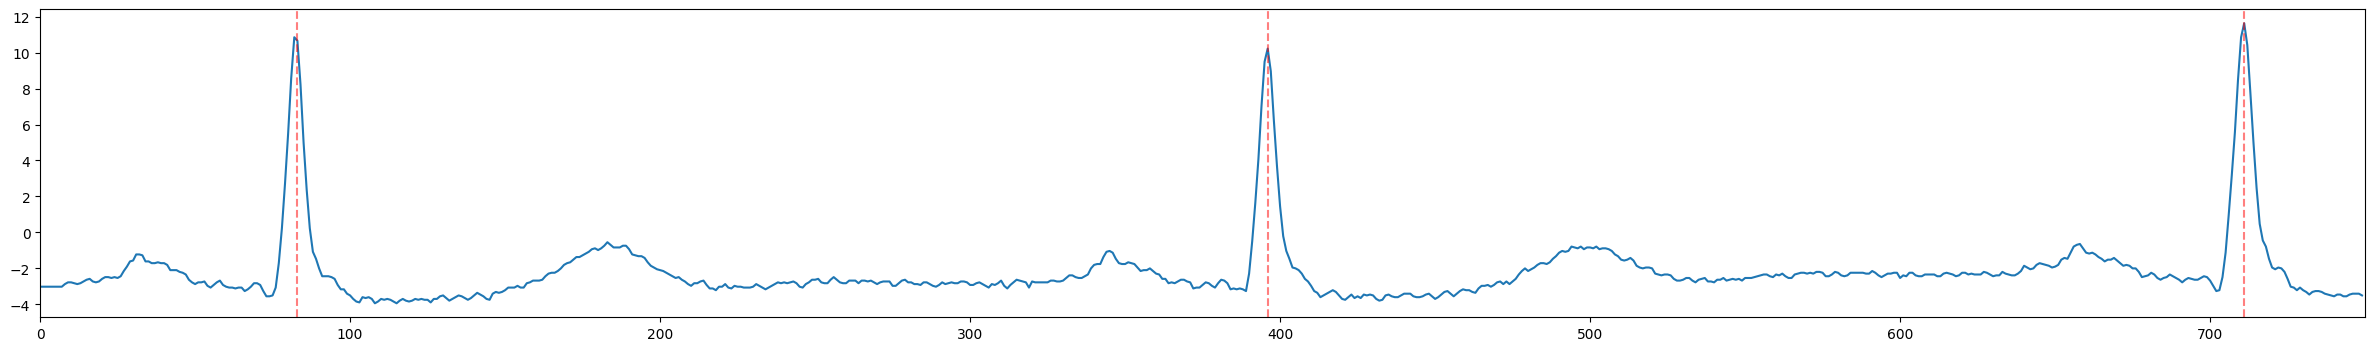

In [ ]:
print(len(dataset_mit))
sample = dataset_mit[1]

print('r_peaks shape:', sample['r_peaks'].shape)
print('labels shape:', sample['label'].shape) 


# plot sample and labels

def plot_sample(sample, start, end):
    plt.figure(figsize=(30, 4))
    signal = sample['signal'][start:end, 1]
    plt.plot(signal.numpy())
    plt.xlim(0, len(signal))
    
    # Convert x-axis ticks to seconds
    #plt.xticks(
    #    ticks=range(0, len(signal), 3600),  # 360 samples per second, so 3600 for 10-second intervals
    #    labels=[f"{x/360:.1f}s" for x in range(0, len(signal), 3600)]
    #)

    # add a red dotted vertical line when the r_peaks is 1
    for i, r_peak in enumerate(sample['r_peaks']):
        if r_peak == 1 and i < end and i >= start:
            plt.axvline(x=i - start, color='red', linestyle='--', alpha=0.5)

    # add a blue dotted vertical line when the label is not -1
    #for i, label in enumerate(sample['label']):
    #    if label != -1 and i < end and i >= start:
    #        plt.axvline(x=i - start, color='blue', linestyle='--')
    #        lolz = int_to_label(int(label))
    #        # plt.text(i - start, 0, str(lolz), color='blue', fontsize=12, ha='center', va='bottom')

plot_sample(sample, 0, 750)

In [ ]:
from utils.train_utils import patch_target_pointwise
from dataset.mit_bih import collate_fn

dataloader = DataLoader(dataset_mit, batch_size=10, shuffle=True, collate_fn=collate_fn)

print('len dataloader:', len(dataloader))

batch = next(iter(dataloader))
# print('batch:', batch)
print('label shape:', batch['label'].shape) # [bs, num_leads, seq_len]  
#print('targets', batch['label'])
#print('targes[0]:', batch['label'][0][512:768])

targets = patch_target_pointwise(batch['label'], patch_size=64, ignore_index=-1) # [bs, num_patch]
#print('targets shape:', targets.shape)
#print('targets:', targets)
#print('targets[0]:', targets[0])

patch_size = 64
t = batch['label'].unfold(1, patch_size, patch_size).max(dim=-1)[0]
print('t shape:', t.shape) # [bs, num_leads, num_patches, patch_size]
print('t:', t)
print('t[0]:', t[3])

signal = batch['signal']

import models.modules as modules
enriched_emb = modules.EnrichedLinearPatchEmbedding(
    num_channels=12,
    num_hiddens=512,
    patch_size=64,
).to('cuda')

x = enriched_emb(signal.permute(0,2,1).to('cuda'))
print('x shape:', x.shape) # [bs, num_patches, num_hiddens]


len dataloader: 337
label shape: torch.Size([10, 10800])
t shape: torch.Size([10, 168])
t: tensor([[-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        ...,
        [-1., -1., -1.,  ...,  0., -1., -1.],
        [-1., -1., -1.,  ...,  0., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.]])
t[0]: tensor([-1., -1., -1., -1., -1.,  0., -1., -1., -1.,  0., -1., -1.,  0., -1.,
        -1., -1.,  0., -1., -1., -1.,  0., -1., -1.,  0., -1., -1., -1.,  0.,
        -1., -1., -1.,  0., -1., -1., -1.,  0., -1., -1., -1.,  0., -1., -1.,
        -1.,  0., -1., -1., -1.,  0., -1., -1., -1.,  0., -1., -1.,  0., -1.,
        -1., -1.,  0., -1., -1., -1.,  0., -1., -1., -1.,  0., -1., -1., -1.,
         0., -1., -1., -1.,  0., -1., -1., -1.,  0., -1., -1., -1.,  0., -1.,
        -1., -1.,  0., -1., -1., -1.,  0., -1., -1., -1.,  0., -1., -1., -1.,
         0., -1., -1., -1.,  0., -1., -1., -1.,  0., -1., -1., -1.,

In [ ]:
import torch
import math

def patch_target_pointwise(
    target: torch.Tensor,
    patch_size: int,
    ignore_index: int = -1
) -> torch.Tensor:
    """
    Assigns a point-wise target label to its corresponding patch.

    Args:
        target: Input tensor of shape [batch_size, seq_len] containing class labels
                at specific points and `ignore_index` elsewhere. Assumes at most
                one non-ignore_index value per row.
        patch_size: The size of each patch in the original sequence length dimension.
        num_patches: The total number of patches in the output representation.
                     This must match the second dimension of the desired output tensor.
        ignore_index: The value indicating ignored/padded elements. Defaults to -1.

    Returns:
        A tensor of shape [batch_size, num_patches] where:
        - `patched_target[b, p]` is the target label if the original target point
          for batch `b` falls within patch `p`.
        - `patched_target[b, p]` is `ignore_index` otherwise.

    Raises:
        ValueError: If input tensor is not 2D, or if patch_size or num_patches
                    are not positive integers.
        TypeError: If input is not a torch.Tensor.
    """
    if not isinstance(target, torch.Tensor):
        raise TypeError(f"Expected target to be a torch.Tensor, but got {type(target)}")
    if target.ndim != 2:
        raise ValueError(f"Expected target to be 2D (batch_size, seq_len), but got shape {target.shape}")
    if not isinstance(patch_size, int) or patch_size <= 0:
        raise ValueError(f"Expected patch_size to be a positive integer, but got {patch_size}")

    batch_size, seq_len = target.shape
    device = target.device
    dtype = target.dtype # Keep the original dtype (usually long for labels)

    # Find the maximum value (target label) and its index along the sequence dimension
    # If all are ignore_index, max will be ignore_index.
    target_vals, target_indices = torch.max(target, dim=1)

    # Create a mask to identify rows that actually have a target label
    # (i.e., where the max value is not the ignore_index)
    has_target_mask = target_vals != ignore_index

    # Calculate the patch index for *all* rows.
    # For rows without a target, this value is meaningless but harmless for now.
    # // performs integer division.
    patch_indices = target_indices // patch_size

    num_patches = math.ceil(seq_len / patch_size)
    # Ensure the patch indices are within the valid range [0, num_patches-1]
    # Initialize the output tensor with the ignore_index
    patched_target = torch.full((batch_size, num_patches), ignore_index, dtype=dtype, device=device)

    # --- Update the output tensor only for rows with valid targets ---

    # Get the batch indices where a target exists
    valid_batch_indices = torch.nonzero(has_target_mask).squeeze(1)

    # If there are no valid targets in the batch, we can return the initialized tensor
    if valid_batch_indices.numel() == 0:
        return patched_target

    # Get the corresponding target values and calculated patch indices for these valid rows
    valid_target_vals = target_vals[has_target_mask]
    valid_patch_indices_raw = patch_indices[has_target_mask]

    # Clamp patch indices to ensure they are within the valid range [0, num_patches-1]
    # This handles cases where the target index might be in padding beyond the
    # sequence length effectively covered by num_patches * patch_size.
    valid_patch_indices = torch.clamp(valid_patch_indices_raw, 0, num_patches - 1)

    # Use advanced indexing to place the target values at the correct [batch, patch] locations
    patched_target[valid_batch_indices, valid_patch_indices] = valid_target_vals

    return patched_target

# --- Example Usage ---

# Assume:
# batch_size = 4
# seq_len = 256
# patch_size = 64
# num_patches = seq_len // patch_size = 4 (assuming no overlap/padding issues)
# ignore_index = -1

target_example = torch.full((4, 256), -1, dtype=torch.long) # Use long for class labels

# Row 0: Target class 5 at index 70 (should fall in patch 1, since 70 // 64 = 1)
target_example[0, 70] = 5

# Row 1: Target class 2 at index 10 (should fall in patch 0, since 10 // 64 = 0)
target_example[1, 10] = 2

# Row 2: All ignored
# target_example[2, :] remains -1

# Row 3: Target class 9 at index 200 (should fall in patch 3, since 200 // 64 = 3)
target_example[3, 200] = 9

patch_size_example = 64
num_patches_example = 256 // patch_size_example # = 4

# Generate the patched target
patched_target_example = patch_target_pointwise(
    target_example,
    patch_size=patch_size_example,
    ignore_index=-1
)

print("Original Target Tensor (showing relevant parts):")
print("Row 0, index 70:", target_example[0, 70].item())
print("Row 1, index 10:", target_example[1, 10].item())
print("Row 2, max value:", torch.max(target_example[2]).item())
print("Row 3, index 200:", target_example[3, 200].item())
print(f"\nOriginal Shape: {target_example.shape}")


print("\nPatched Target Tensor:")
print(patched_target_example)
print(f"\nShape: {patched_target_example.shape}")

# Verification:
# Expected output:
# [[-1,  5, -1, -1],
#  [ 2, -1, -1, -1],
#  [-1, -1, -1, -1],
#  [-1, -1, -1,  9]]

Original Target Tensor (showing relevant parts):
Row 0, index 70: 5
Row 1, index 10: 2
Row 2, max value: -1
Row 3, index 200: 9

Original Shape: torch.Size([4, 256])

Patched Target Tensor:
tensor([[-1,  5, -1, -1],
        [ 2, -1, -1, -1],
        [-1, -1, -1, -1],
        [-1, -1, -1,  9]])

Shape: torch.Size([4, 4])


RuntimeError: Boolean value of Tensor with more than one value is ambiguous

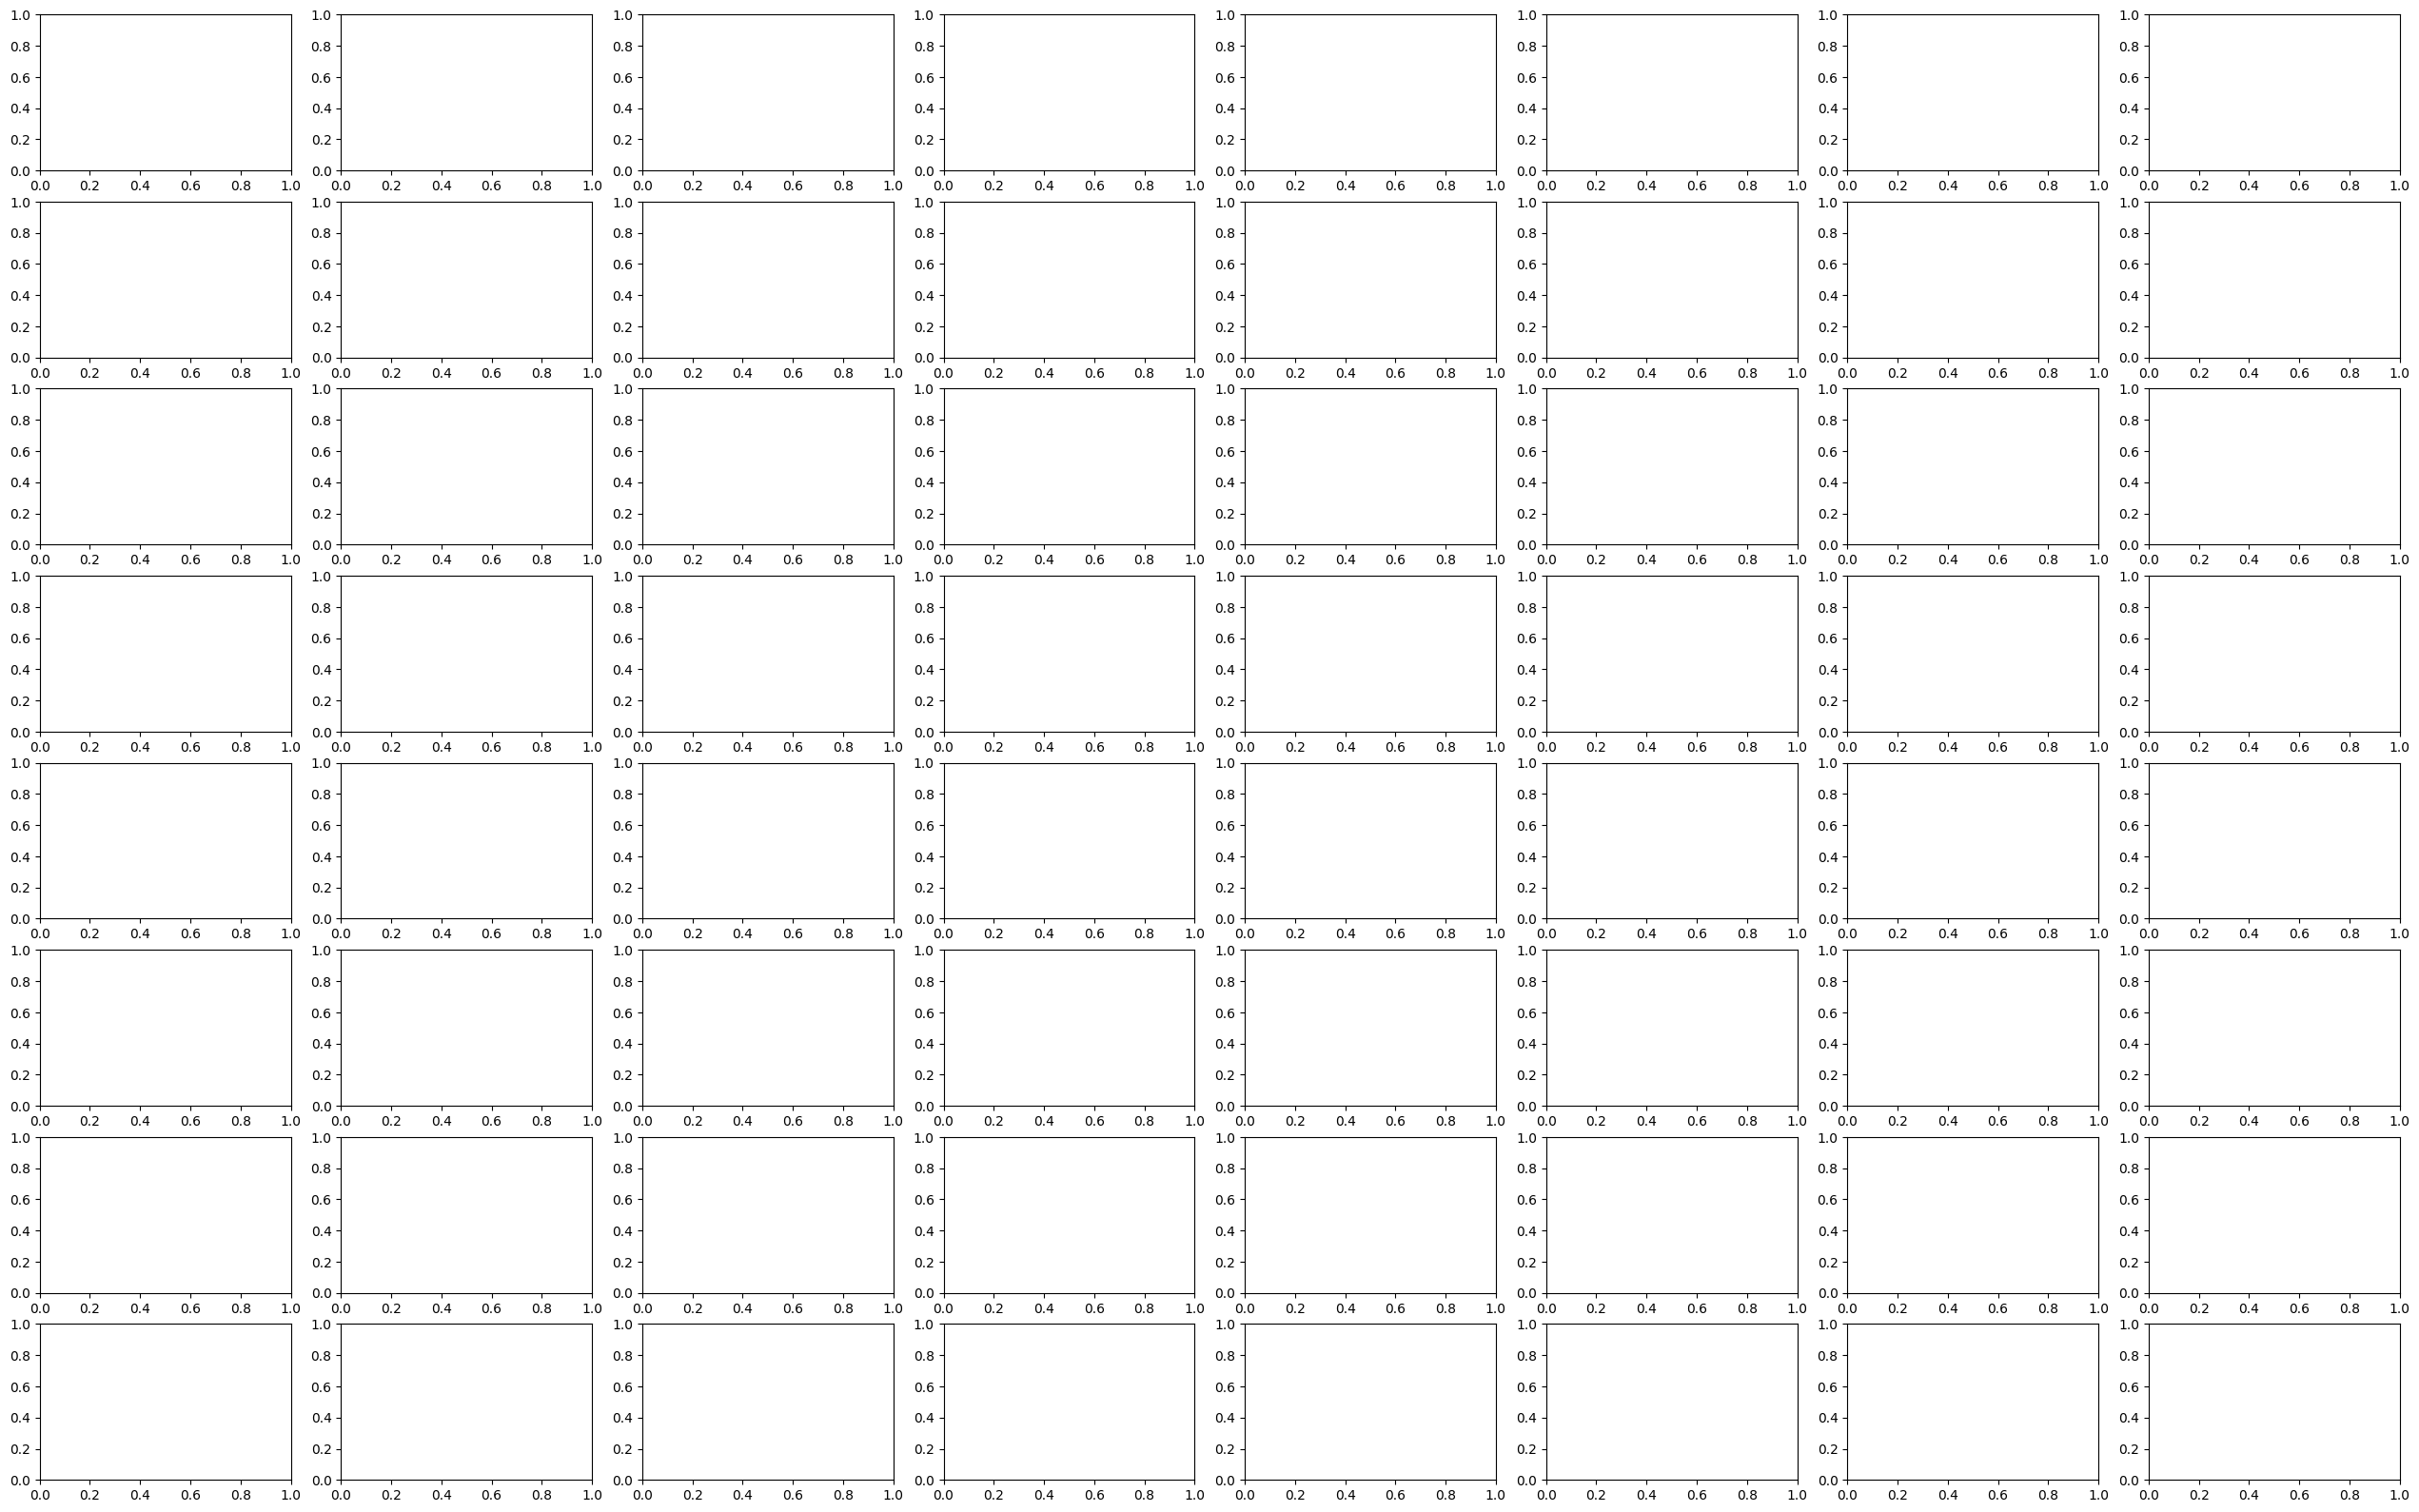

In [ ]:
# plot 64 in 8x8 grid hearbeats
import matplotlib.pyplot as plt

def plot_samples(dataset, class_id):
    fig, axs = plt.subplots(8, 8, figsize=(32, 20))
    count = 0
    for i in range(64):
        if count >= len(dataset):
            break
        label = dataset[count]['label']
        while label != class_id:
            count += 1
            if count >= len(dataset):
                break
            label = dataset[count]['label']
        # print('stralol')

        if count >= len(dataset):
            break
        x = dataset[count]['heartbeat'][:, 1]
        count += 1
        axs[i//8, i%8].plot(x)
        axs[i//8, i%8].set_title(count)
        axs[i//8, i%8].set_yticks([])
        axs[i//8, i%8].set_xticks([])

        while label == class_id and count < len(dataset):
            count += 1
            if count >= len(dataset):
                break
            label = dataset[count]['label']
            

    plt.show()

plot_samples(dataset_mit, 0) # N
plot_samples(dataset_mit, 1) # V
plot_samples(dataset_mit, 2) # S
plot_samples(dataset_mit, 3) # F
plot_samples(dataset_mit, 4) # Q

In [ ]:
from tqdm import tqdm

train = [101, 106, 108, 109, 112, 114, 115, 116, 118, 119, 122, 124, 201, 203, 205, 207, 208, 209, 215, 220, 223, 230]
test = [100, 103, 105, 111, 113, 117, 121, 123, 200, 202, 210, 212, 213, 214, 219, 221, 222, 228, 231, 232, 233, 234]

patients = { p: [0, 0, 0, 0, 0] for p in test }

for d in tqdm(dataset_mit_test):
   arr = patients[d['patient_id']] 
   arr[d['label']] += 1

print(patients)

# count by label
labels = [0, 0, 0, 0, 0]
for p in patients:
    for i in range(5):
        labels[i] += patients[p][i]
print(labels)

100%|██████████| 49712/49712 [00:18<00:00, 2639.09it/s]

{100: [2239, 33, 1, 0, 0], 103: [2082, 2, 0, 0, 0], 105: [2526, 0, 41, 0, 5], 111: [2123, 0, 1, 0, 0], 113: [1789, 6, 0, 0, 0], 117: [1534, 1, 0, 0, 0], 121: [1861, 1, 1, 0, 0], 123: [1515, 0, 3, 0, 0], 200: [1743, 30, 826, 2, 0], 202: [2061, 55, 19, 1, 0], 210: [2423, 22, 195, 10, 0], 212: [2748, 0, 0, 0, 0], 213: [2641, 28, 220, 362, 0], 214: [2003, 0, 256, 1, 2], 219: [2082, 7, 64, 1, 0], 221: [2031, 0, 396, 0, 0], 222: [2274, 209, 0, 0, 0], 228: [1688, 3, 362, 0, 0], 231: [1568, 1, 2, 0, 0], 232: [398, 1382, 0, 0, 0], 233: [2230, 7, 831, 11, 0], 234: [2700, 50, 3, 0, 0]}
[44259, 1837, 3221, 388, 7]


In [ ]:
from utils.utils import get_training_class_weights

weights = get_training_class_weights(dataset_mit, do_not_consider_classes=[4])





Class Counts: Counter({0: 45866, 2: 3788, 1: 944, 3: 415})
Class Weights: tensor([ 0.2781, 13.5098,  3.3668, 30.7307])


In [ ]:
#  class_weights = {cls: total_samples / (3 * count) for cls, count in class_counts.items()}

classes = [45866, 3788, 944]
weights =  (np.sum(classes)) / [c * 3 for c in classes]
print('weights:', weights)

weights: [ 0.36772337  4.45248152 17.86652542]


In [ ]:
import pandas as pd

pd.read_csv('/media/Volume/data/CODE15/exams.csv').head()

,Unnamed: 0,exam_id,age,is_male,nn_predicted_age,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,timey,normal_ecg,trace_file,r_peaks,r_peak_interval_mean,r_peak_variance
0,0,1169160,38,True,40.160484,False,False,False,False,False,False,523632,False,2.098628,True,exams_part13.hdf5,[ 57 285 507 742 972 1196 1419 1630 1848 ...,0.625309,0.020557
1,1,2873686,73,True,67.059440,False,False,False,False,False,False,1724173,False,6.657529,False,exams_part13.hdf5,[ 219 460 702 944 1176 1404 1631 1859 2080],0.646181,0.020969
2,2,168405,67,True,79.621740,False,False,False,False,False,True,51421,False,4.282188,False,exams_part13.hdf5,[ 220 532 716 1024 1200 1599 1874],0.765741,0.214907
3,3,271011,41,True,69.750260,False,False,False,False,False,False,1737282,False,4.038353,True,exams_part13.hdf5,[ 306 585 868 1142 1434 1725 2004 2290 2595 ...,0.795679,0.024149
4,4,384368,73,True,78.873460,False,False,False,False,False,False,331652,False,3.786298,False,exams_part13.hdf5,[ 115 285 454 623 793 962 1132 1303 1474 ...,0.473090,0.002729


signal shape torch.Size([2112, 12])
jittered signal shape torch.Size([2112, 12])
ft signal shape torch.Size([2112, 12])
frequency shifted signal shape torch.Size([2112, 12])


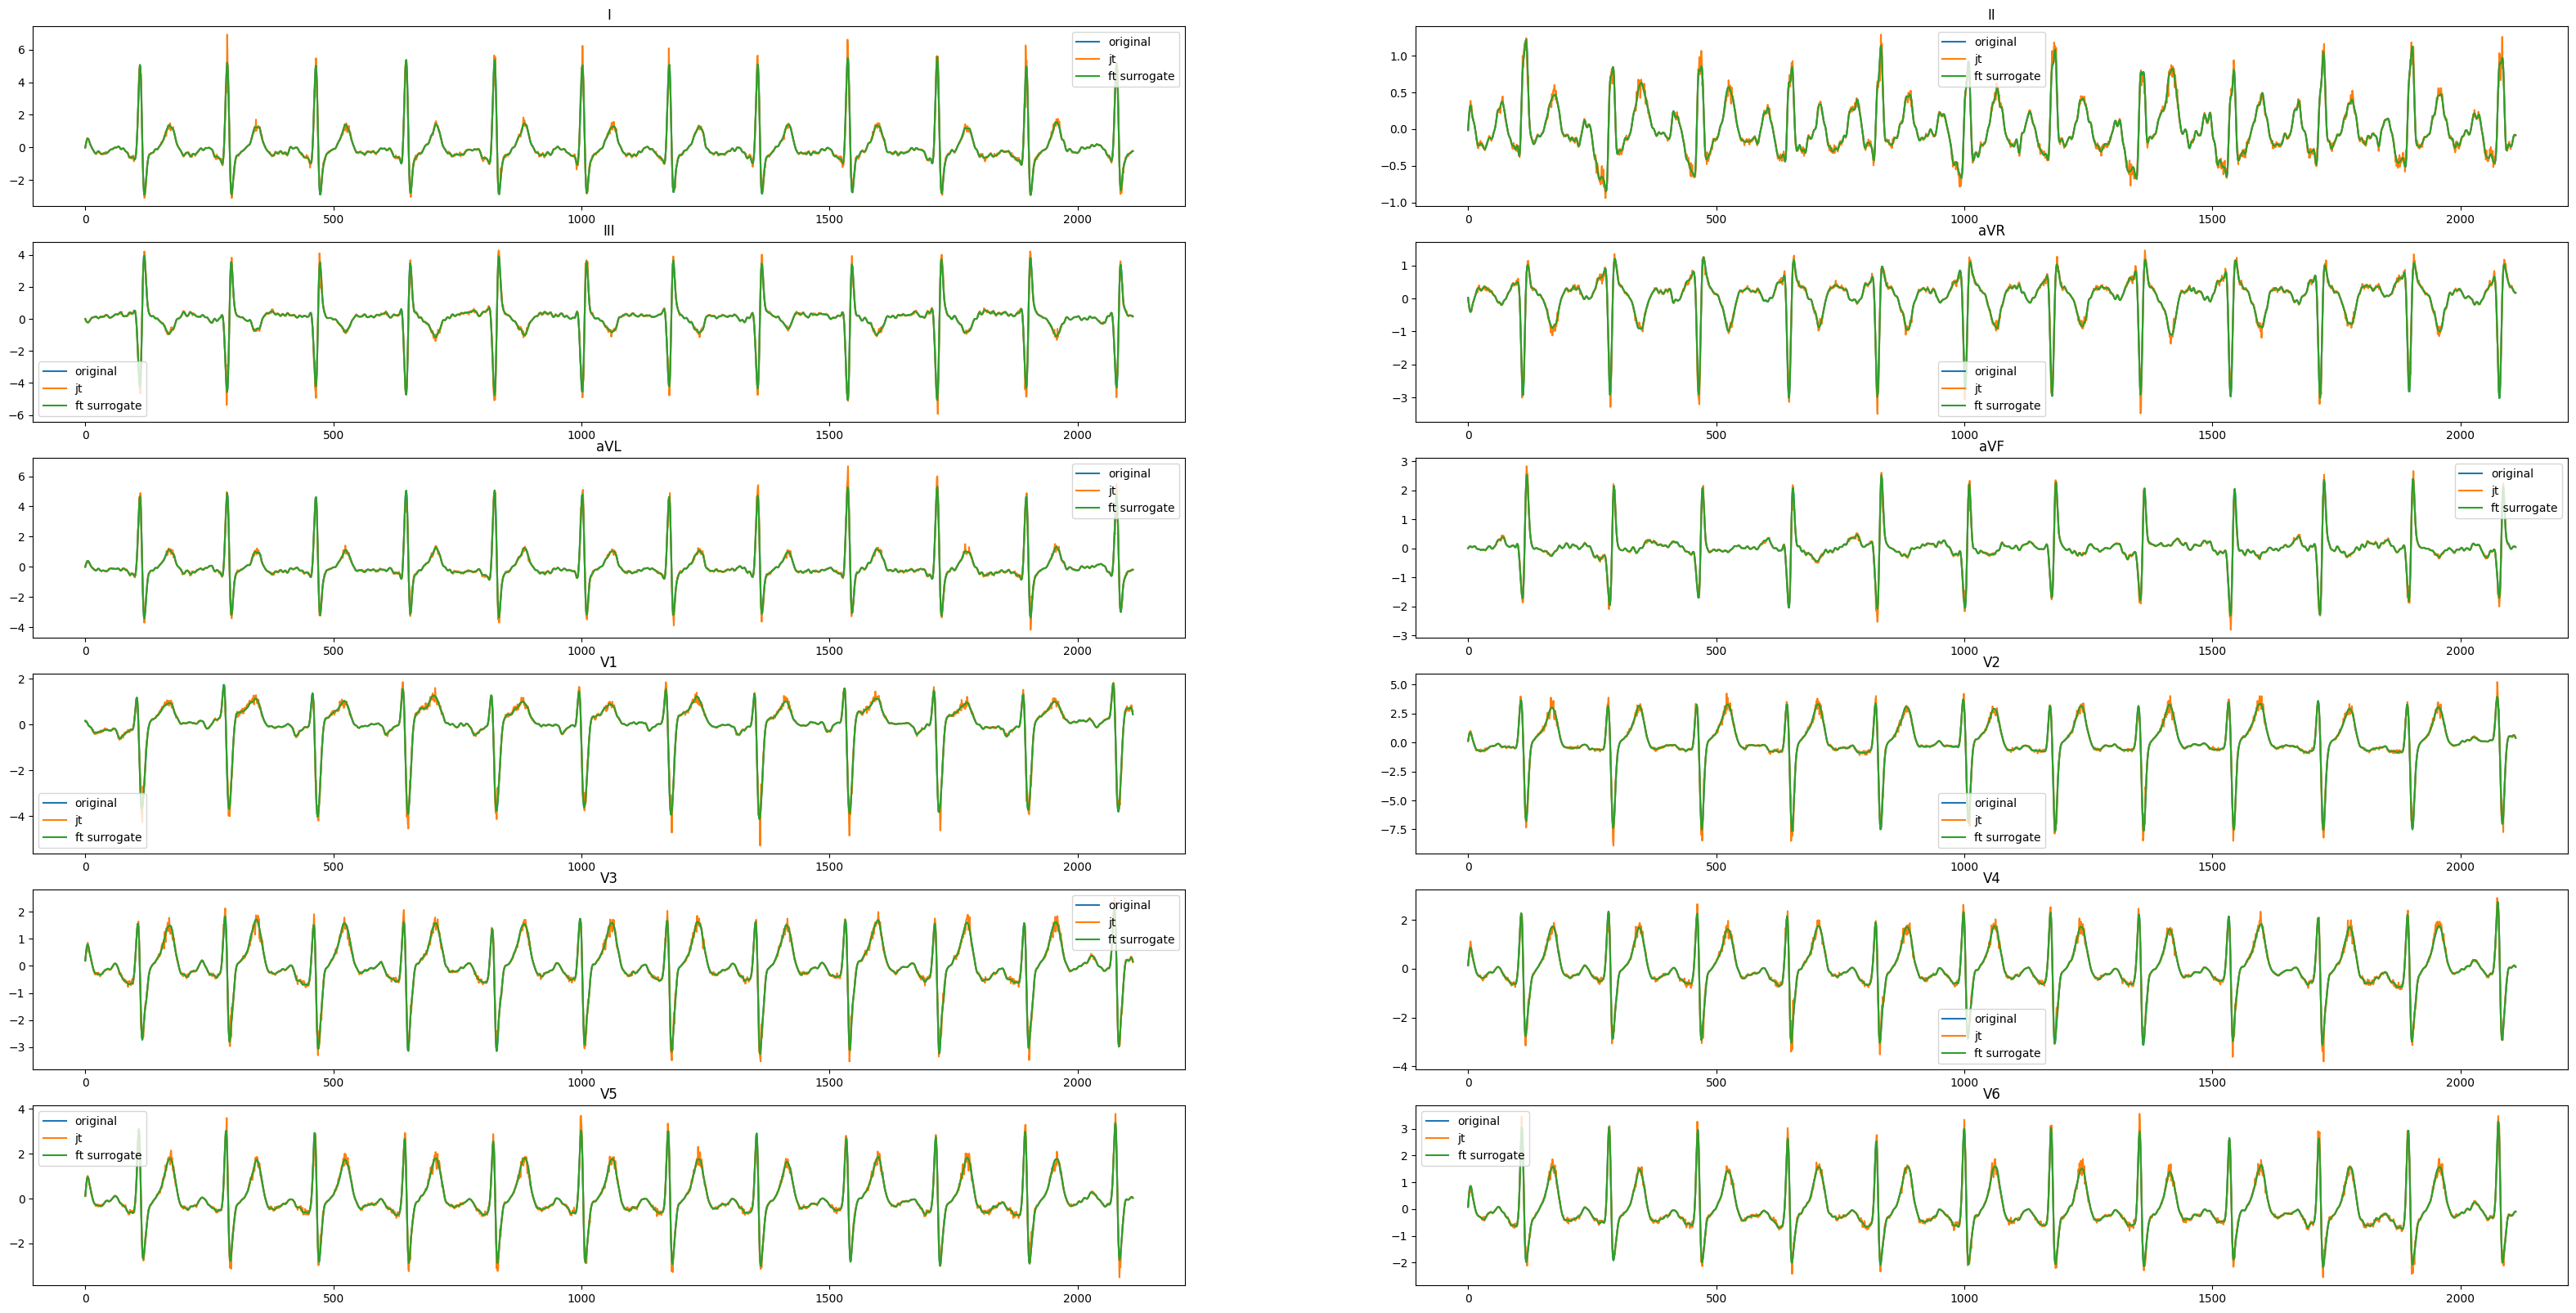

In [ ]:
# plot the 12 lead signal
from augmentations import Jitter, FTSurrogate, SpecAugment, CropResizing, FrequencyShift

signal = dataset[89789]['signal']
leads = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
jt = Jitter(sigma=0.2)
jt_signal = jt(signal.unsqueeze(0)).squeeze()
ft_surrogate = FTSurrogate(0.5, channel_indep=False, prob=0.1)
ft_signal = ft_surrogate(signal.unsqueeze(0)).squeeze() 
fs = FrequencyShift(1)
fs_signal = fs(signal)

# cp = CropResizing(0.9, 0.9)
# cp_signal = cp(signal)

print('signal shape', signal.shape)
print('jittered signal shape', jt_signal.shape)
print('ft signal shape', ft_signal.shape)
# print('crop resized signal shape', cp_signal.shape)
print('frequency shifted signal shape', fs_signal.shape)

import matplotlib.pyplot as plt
import numpy as np


fig, axs = plt.subplots(6, 2, figsize=(40, 20))

for i in range(12):
    ax = axs[i//2, i%2]
    ax.plot(signal[:, i])
    ax.plot(jt_signal[:, i])
    ax.plot(ft_signal[:, i])
    # ax.plot(cp_signal[:, i])
    # ax.plot(fs_signal[:, i])

    ax.set_title(leads[i])

    ax.legend(['original', 'jt', 'ft surrogate',])

    



In [ ]:
# plot the gradient of a ssignal

sample = dataset[0]
shift_x, shift_reconstruct = get_reconstruction(sample, xlstm, patch_size)
print(shift_x.shape)
gradient = shift_x[:, :-1] - shift_x[:, 1:]
gradient_reconstruct = shift_reconstruct[:, :-1] - shift_reconstruct[:, 1:]
mse_grad = F.mse_loss(gradient, gradient_reconstruct, reduction='none')


fig = plt.figure(figsize=(20, 5))
plt.plot(gradient.cpu().squeeze().numpy(), color=color_1)
plt.plot(gradient_reconstruct.cpu().squeeze().numpy(), color=color_2)
plt.plot(mse_grad.cpu().squeeze().numpy(), color='green')
plt.legend(['Original', 'Reconstructed', 'MSE'])
#plt.plot(shift_x[:, :].cpu().squeeze().numpy(), color=color_2)
plt.show()

fig = plt.figure(figsize=(20, 5))
plt.plot(shift_x[:, :].cpu().squeeze().numpy(), color=color_2)
plt.plot(shift_reconstruct[:, :].cpu().squeeze().numpy(), color=color_1)
plt.legend(['Original', 'Reconstructed'])
plt.show()


NameError: name 'shift_x' is not defined

sample shape torch.Size([1, 3712, 1])
prediction_tokens shape torch.Size([1, 2560])
predictions shape torch.Size([2560])


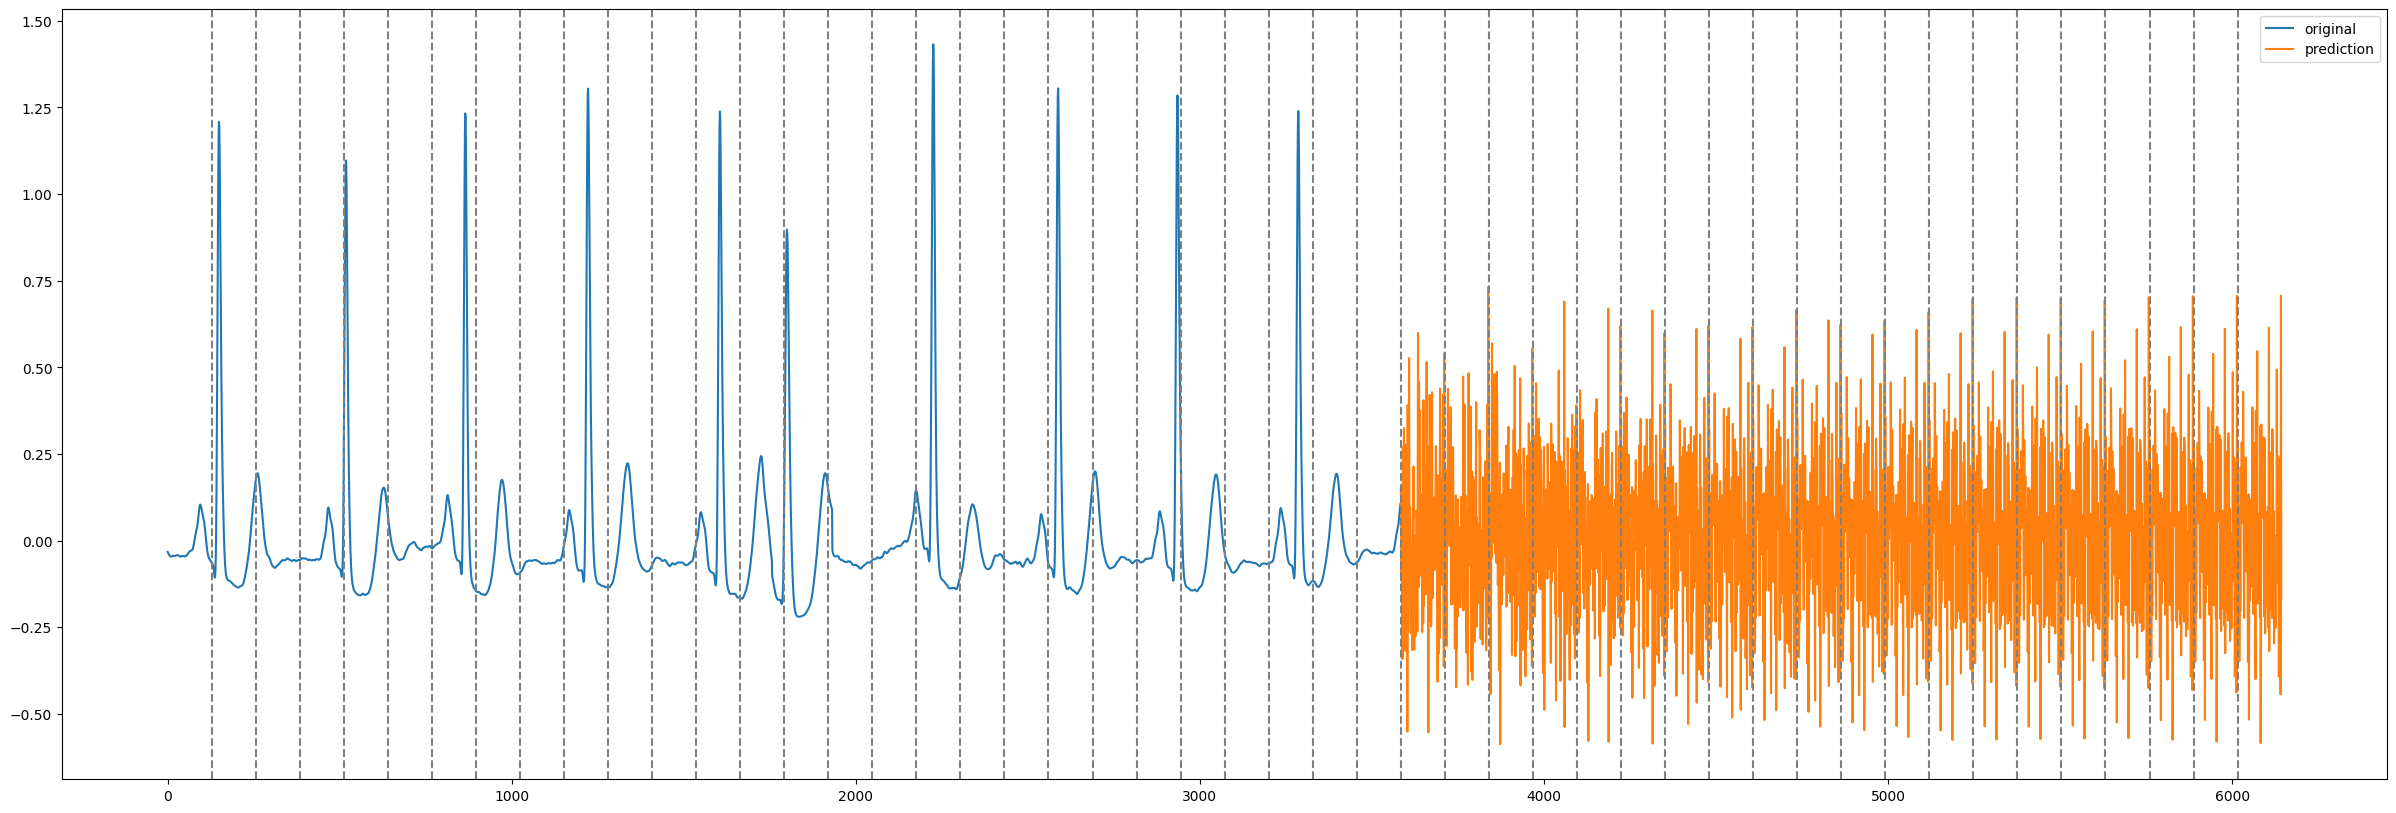

In [ ]:
# given the sample predict a new signal

# get the prediction
#sample = sample[:, :600]
print('sample shape', sample.shape)
prediction_tokens = torch.zeros([1, 0]).to('cuda')
for i in range(0, 20):
    if i == 0:
        new_sample = sample
    else:
        flatten_preds = prediction_tokens.view(1, -1)
        # print('flatten_preds shape', flatten_preds.shape)
        # print('sample shape', sample.shape)
        new_sample = torch.cat([sample, flatten_preds.unsqueeze(-1)], dim=1)
        # print('new_sample shape', new_sample.shape)
    # print('new_sample shape', new_sample.shape)
    r1, r2, r3, r4 = xlstm.reconstruct(new_sample, tab_data=tab_data)
    # print('reconstruct shape', reconstruct.shape)
    # the last token is the prediction
    p1 = r1[:, -patch_size:]
    p2 = r2[:, -patch_size:]
    p3 = r3[:, -patch_size:]
    p4 = r4[:, -patch_size:]
    # print('prediction shape', prediction.shape)
    # print('prediction_tokens shape', prediction_tokens.shape)
    # print('prediction shape', prediction.shape)
    # print('prediction_tokens shape', prediction_tokens.shape)
    prediction_tokens = torch.cat([prediction_tokens, p1], dim=1) #, p2, p3, p4], dim=1)

print('prediction_tokens shape', prediction_tokens.shape)
predictions = prediction_tokens.squeeze().view(-1)
print('predictions shape', predictions.shape)

# plot the signal
plt.figure(figsize=(30, 10))
plt.plot(sample[0, :-patch_size].squeeze().cpu().numpy(), label='original')
plt.plot(range(len(sample[0, :-patch_size]), len(sample[0, :-patch_size]) + len(predictions)), predictions.detach().cpu().numpy(), label='prediction')
# add a pipe avery 64 samples
for i in range(1, (len(sample[0]) + len(predictions)) // patch_size -1):
   plt.axvline(x=patch_size*i, color='gray', linestyle='--')
plt.legend()

In [ ]:
import dataset.code_15 as code_15
import torch
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt    
from tqdm import tqdm

train_dataset = code_15.ECGCODE15Dataset('/media/Volume/data/CODE15/unlabeled_records_360', num_leads=12, random_shift=True, patch_size=64, normalize=False)
train_dataset_cleaned = code_15.ECGCODE15Dataset('/media/Volume/data/CODE15/unlabeled_records_360_nkclean', num_leads=12, random_shift=True, patch_size=64, normalize=False)

loaded 343287 records
tabular data fields for CODE 15:  Index(['age', 'is_male', '1dAVb', 'RBBB', 'LBBB', 'SB', 'ST', 'AF',
       'normal_ecg'],
      dtype='object')
loaded 343287 records
tabular data fields for CODE 15:  Index(['age', 'is_male', '1dAVb', 'RBBB', 'LBBB', 'SB', 'ST', 'AF',
       'normal_ecg'],
      dtype='object')


low 1
high 605
middle 342681


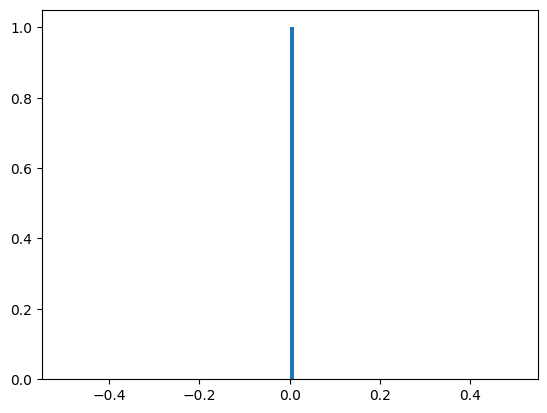

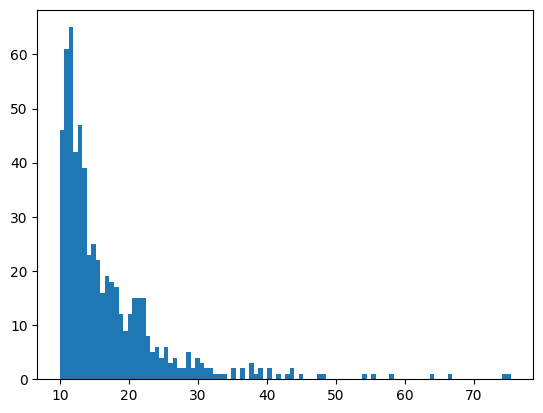

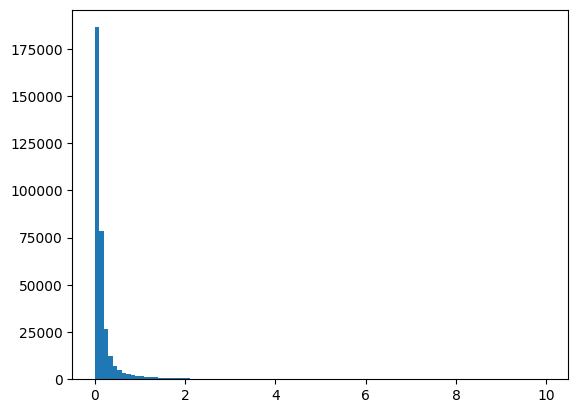

In [ ]:
variances = [v[1] for v in vars]
low_variances = [v for v in variances if v < 0.0001]
print('low', len(low_variances))
hihg_variances = [v for v in variances if v > 10 ]
len(hihg_variances)
print('high', len(hihg_variances))
middle_variances = [v for v in variances if v > 0.0001 and v < 10]
len(middle_variances)
print('middle', len(middle_variances))

# plot the histogram of the signal length
plt.hist(low_variances, bins=100)
plt.show()
plt.hist(hihg_variances, bins=100)
plt.show()
plt.hist(middle_variances, bins=100)
plt.show()

number of samples 8
number of samples with high variance 0


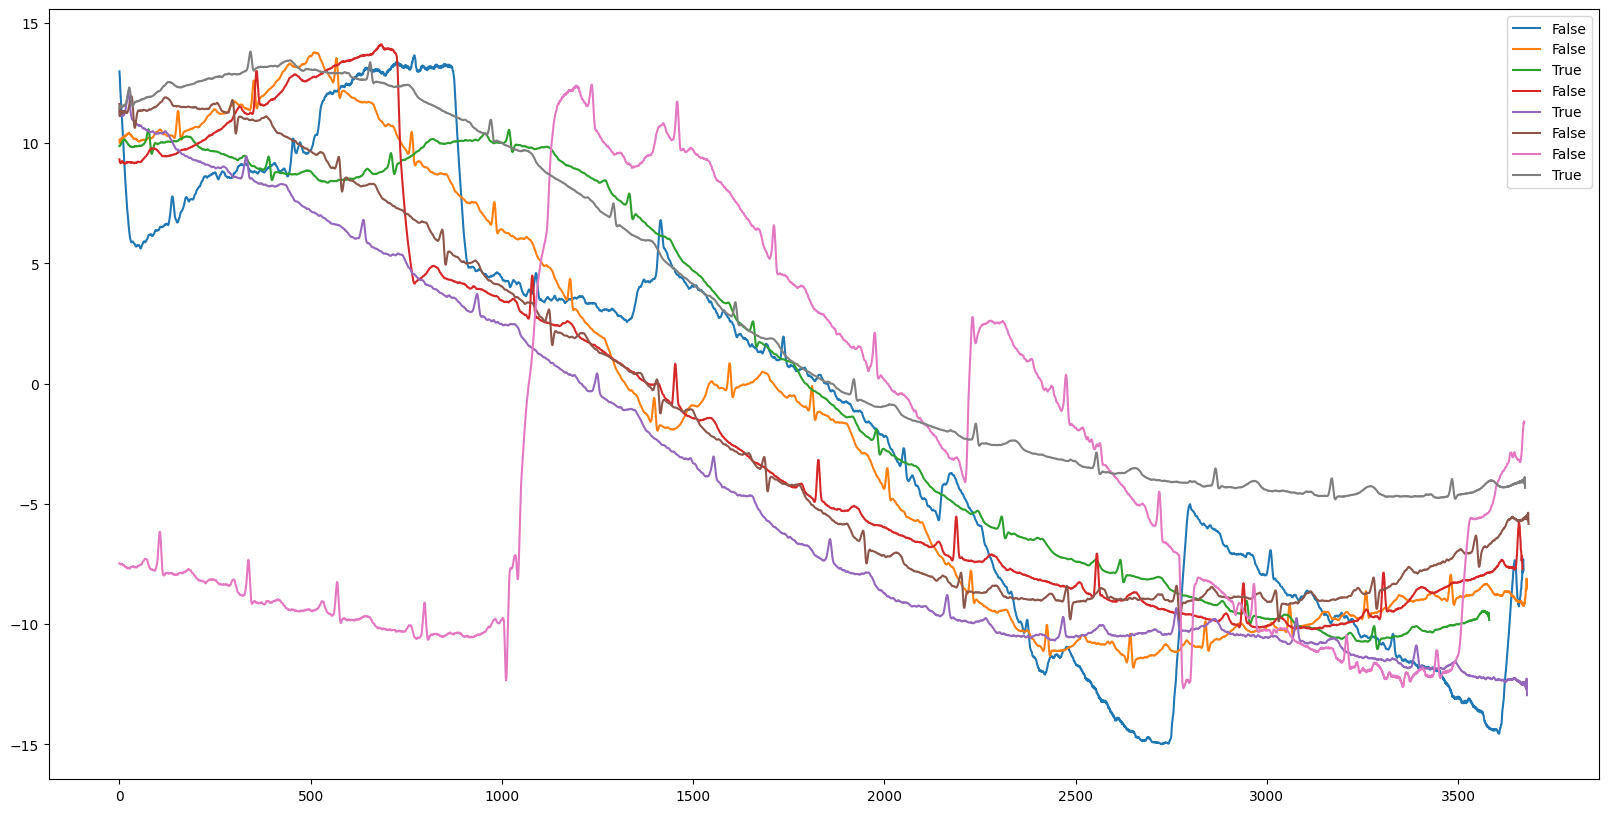

In [ ]:
# get the index of the signal with highest variance
max_idx = sorted(vars, key=lambda x: x[1])
# plot the signal with the highest variance

# plot the first 10 samples
count = 0
plt.figure(figsize=(20, 10))
for i in range(1, len(max_idx)):
    sample = train_dataset[max_idx[-i][0]]['signal']
    # sample = (sample - sample.mean()) / sample.std()

    max_val = sample.max().item()
    min_val = sample.min().item()
    tab_data = train_dataset[max_idx[-i][0]]['tab_data']
    # if (max_val > 15 or min_val < -15):
    #print('tab_data', tab_data)
    plt.plot(train_dataset[max_idx[-i][0]]['signal'].squeeze().cpu().numpy(), label=f'{tab_data.loc["normal_ecg"].values[0]}')
    if max_idx[-i][1] < 50:
        break

print('number of samples', i)
print('number of samples with high variance', count)
plt.legend()
plt.show()

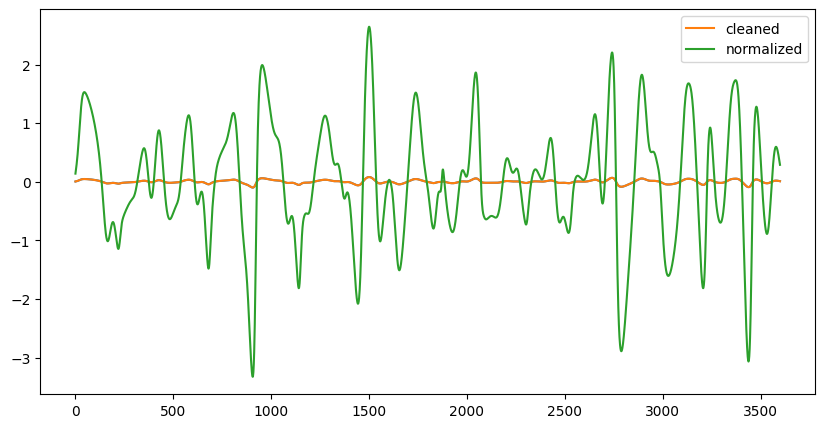

In [ ]:
from torch import nn    

class moving_avg(nn.Module):
    """
    Moving average block to highlight the trend of time series
    """
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # padding on the both ends of time series
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x


class series_decomp(nn.Module):
    """
    Series decomposition block
    """
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean
    

sd = series_decomp(25)


# plot the signal with the highest variance
sample = train_dataset[100]['signal']

plt.figure(figsize=(10, 5))
plt.plot(sample['signal'].squeeze().cpu().numpy())
plt.show()


In [ ]:
batch = next(iter(train_dataloader))

# plot the first sample
x = batch["signal"].to('cuda')
mask = batch["mask"].to('cuda')
tab_data = batch["tab_data"]
# print('initial mask shape', mask.shape)
# print('initial x shape', x.shape)
reconstruct, _, _, _ = xlstm.reconstruct(x, tab_data) 

# get rid of the exeding part on the original signal
shift_x = x[:, :reconstruct.shape[1]]
shift_x = shift_x[:, patch_size:].squeeze()

mask_shifted = mask[:, :reconstruct.shape[1]]
mask_shifted = mask_shifted[:, patch_size:].squeeze()

mask_idxs, lol = torch.where(mask_shifted == 0)
print('lol', lol.shape)

shift_reconstruct = reconstruct[:, :-patch_size]

#print('mask shape', mask.shape)
#print('x shape', x.shape)   
#print('reconstruct shape', shift_reconstruct.shape)

# shift_reconstruct = shift_reconstruct.masked_fill(mask_shifted, 0)
# shift_x = shift_x.masked_fill(mask_shifted, 0)

print('mask_shifted shape', mask_shifted.shape)
print('shift_x shape', shift_x.shape)
print('max_idxs has shape', mask_idxs.shape)
print('max_idxs 0 is ', mask_idxs[0])
print('shift_reconstruct shape', shift_reconstruct.shape)
# add a pipe avery 64 samples

# m = shift_x == mask_idxs
# plot the first sample
plt.figure(figsize=(10, 5))
plt.plot(shift_x[0].squeeze().cpu().numpy(), label='original')
plt.plot(shift_reconstruct[0].squeeze().detach().cpu().numpy(), label='reconstructed')
ma_inp = shift_x[0] * mask_shifted[0]
print('ma_inp shape', ma_inp.shape)
plt.plot(ma_inp.cpu().numpy(), label='lol')
#plot mask
# plt.plot(mask_shifted[0].cpu().numpy(), label='mask')
plt.legend()

In [ ]:
from matplotlib import pyplot as plt    
import dataset.code_15 as code_15

train_dataset = code_15.ECGCODE15Dataset('/media/Volume/data/CODE15/unlabeled_records_360_nkclean', num_leads=12, random_shift=False, patch_size=64, normalize=True)
train_original = code_15.ECGCODE15Dataset('/media/Volume/data/CODE15/unlabeled_records', num_leads=12, random_shift=False, patch_size=64, normalize=False)

train_dataloader = DataLoader(train_dataset, batch_size=10, shuffle=True, collate_fn=code_15.collate_fn)

# plot the first sample


loaded 343287 records
tabular data fields for CODE 15:  Index(['age', 'is_male', '1dAVb', 'RBBB', 'LBBB', 'SB', 'ST', 'AF',
       'normal_ecg'],
      dtype='object')
loaded 345109 records
tabular data fields for CODE 15:  Index(['age', 'is_male', '1dAVb', 'RBBB', 'LBBB', 'SB', 'ST', 'AF',
       'normal_ecg'],
      dtype='object')


torch.Size([4096])


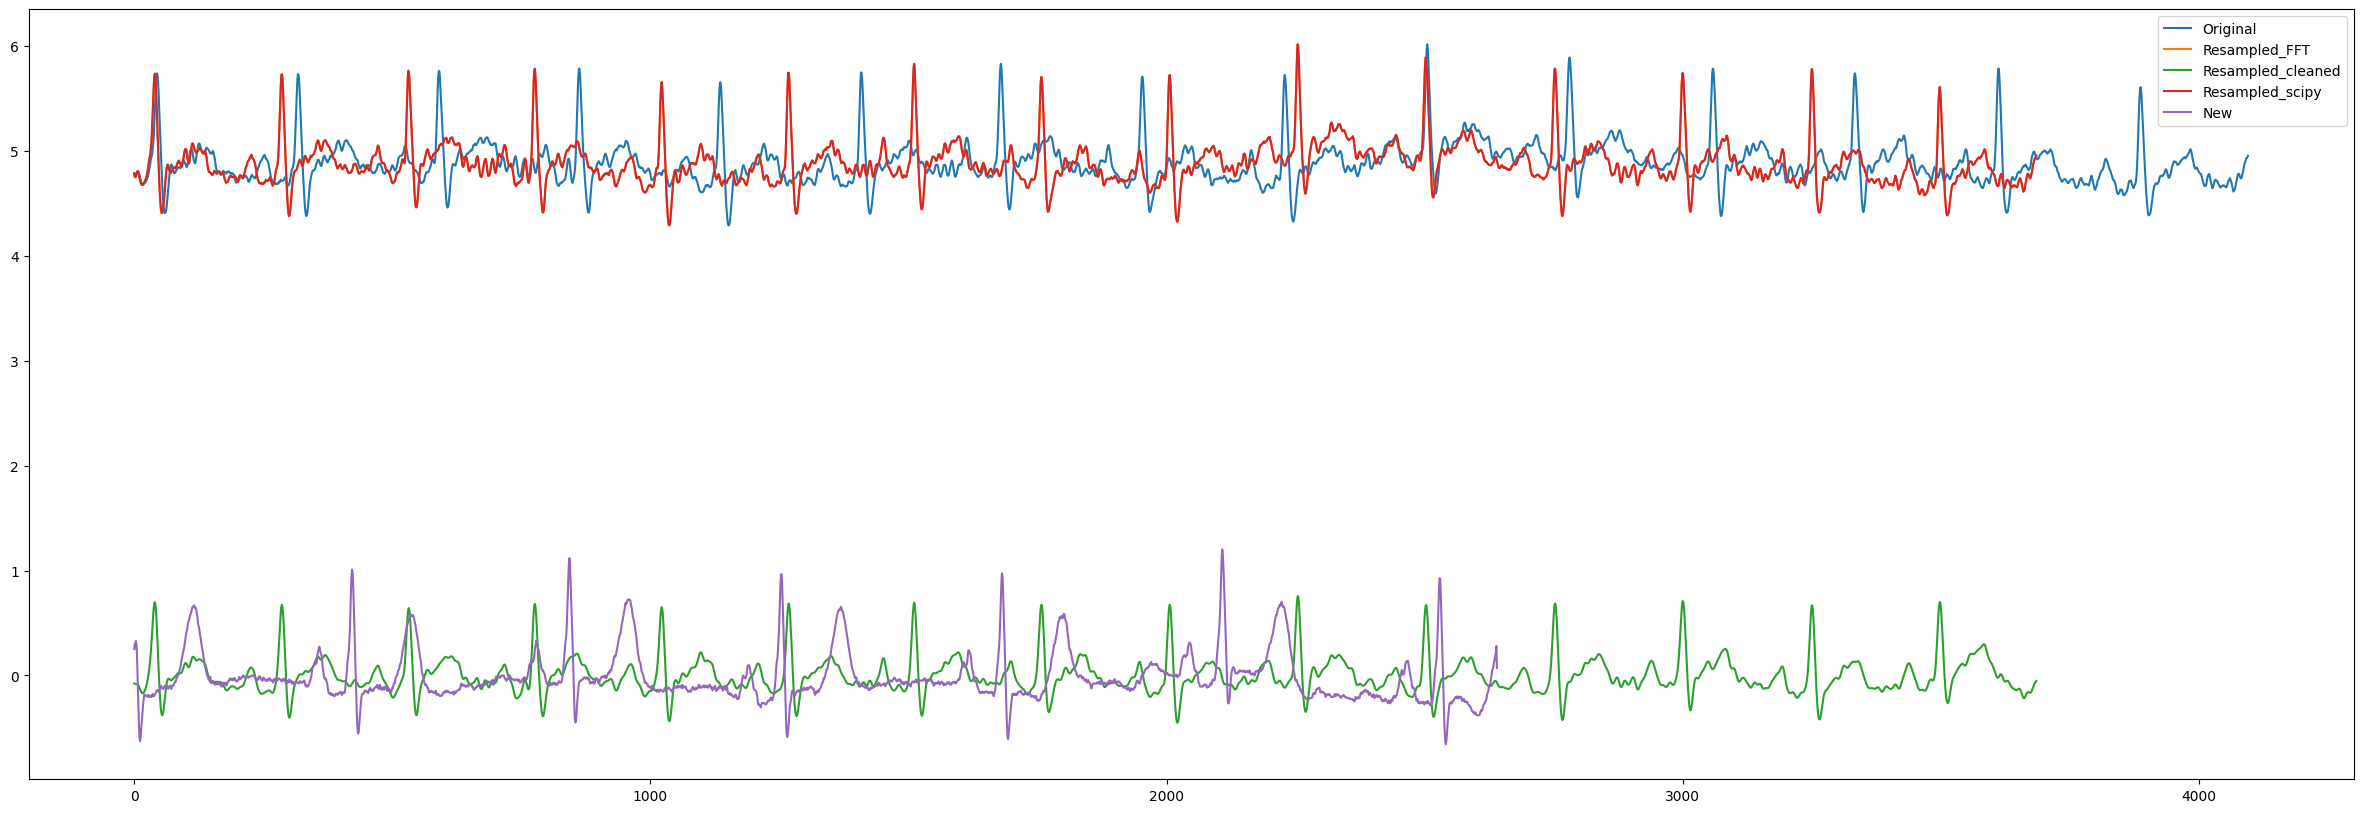

In [ ]:
idx = 9878
sample_orig = train_original[idx]['signal'][:, 1]
sample_new = train_dataset[idx]['signal']
print(sample_orig.shape)
plt.figure(figsize=(30, 10))
plt.plot(sample_orig, label='Original')


resampled = nk.signal_resample(sample_orig, sampling_rate=400, desired_sampling_rate=360, method='FFT')
plt.plot(resampled, label='Resampled_FFT')
resampled = nk.signal_resample(sample_orig, sampling_rate=400, desired_sampling_rate=360, method='FFT')
resampled = nk.ecg_clean(resampled, sampling_rate=360, method='nk')
plt.plot(resampled, label='Resampled_cleaned')
#scipy resample
from scipy.signal import resample
resampled = resample(sample_orig, len(sample_orig) * 360 // 400)
plt.plot(resampled, label='Resampled_scipy')

plt.plot(sample_new, label='New')   

plt.legend()


torch.Size([3686])
torch.Size([10, 3686])
torch.Size([10, 3686])


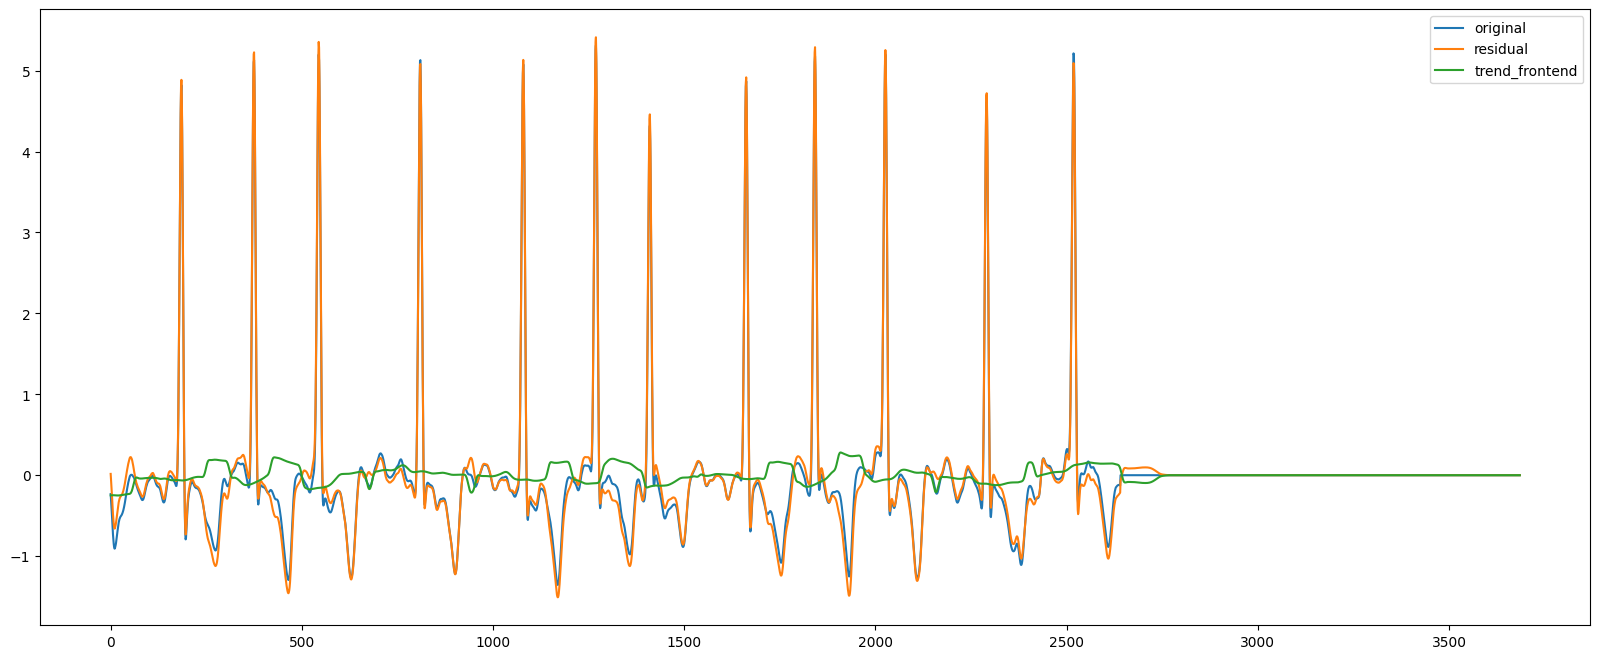

In [ ]:
from torch import nn
class MovingAvg(nn.Module):
    def __init__(self, moving_avg, front_end):
        super(MovingAvg, self).__init__()
        self.kernel_size = moving_avg
        self.avg = nn.AvgPool1d(kernel_size=moving_avg, stride=1, padding=0)
        self.front_end = front_end

    def forward(self, x):
        # padding on the both ends of time series
        if not self.front_end:
            front = x[:, 0:1, :].repeat(1, self.kernel_size-1, 1)
            x = torch.cat([front, x], dim=1)

        else:
            front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
            end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
            x = torch.cat([front, x, end], dim=1)

        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x        
    

class SeriesDecomposition(nn.Module):
    """
    Series decomposition block
    """
    def __init__(self, kernel_size, front_end):
        super(SeriesDecomposition, self).__init__()
        self.moving_avg = MovingAvg(kernel_size, front_end)

    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean
    
sd = SeriesDecomposition(251, front_end=True)
    
sample = next(iter(train_dataloader))

decomposed = sd(sample['signal'])

#fft = torch.fft(sample['signal'], dim=1)

print(sample['signal'][0].squeeze().shape)
print(decomposed[0].squeeze().shape)
print(decomposed[1].squeeze().shape)

# plot the first sample
plt.figure(figsize=(20, 8))
plt.plot(sample['signal'][0].squeeze().cpu().numpy(), label='original')
plt.plot(decomposed[0][0].squeeze().cpu().numpy(), label='residual')
plt.plot(decomposed[1][0].squeeze().cpu().numpy(), label='trend_frontend')
# plt.plot(sd_f(sample['signal'])[0][0].squeeze().cpu().numpy(), label='trend_actual')
plt.legend()
plt.show()





/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your u

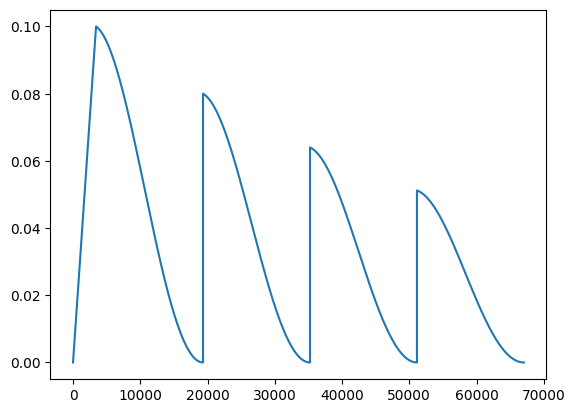

In [ ]:
from torch.optim.lr_scheduler import LambdaLR
import math
import torch
import torch.optim as optim
from matplotlib import pyplot as plt


def get_cosine_with_hard_restarts_schedule_with_warmup_and_decay(
    optimizer, 
    num_warmup_steps, 
    num_training_steps, 
    num_cycles=1, 
    decay_factor=0.9
):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return current_step / max(1, num_warmup_steps)
        
        progress = (current_step - num_warmup_steps) / max(1, num_training_steps - num_warmup_steps)
        cycle_progress = progress * num_cycles % 1  # Progress within the current cycle
        decay = decay_factor ** (progress * num_cycles)  # Apply decay per cycle

        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * cycle_progress))) * decay
    
    return LambdaLR(optimizer, lr_lambda)

model = torch.nn.Linear(10, 1)
optimizer = optim.SGD(model.parameters(), lr=0.1)
steps_per_epoch = 2682
epochs = 25
train_steps = steps_per_epoch * epochs
warmup_steps = steps_per_epoch  * 2

lr_scheduler = get_cosine_with_hard_restarts_schedule_with_warmup_and_decay(
    optimizer, 
    num_warmup_steps=warmup_steps, 
    num_training_steps=train_steps, 
    num_cycles=(train_steps // warmup_steps) // 4, decay_factor=0.8)

lrs = []
for epoch in range(train_steps):
    # train step goes here
    lr_scheduler.step(epoch)
    lrs.append(optimizer.param_groups[0]['lr'])

plt.plot(lrs)

In [ ]:
from torch.optim.lr_scheduler import LambdaLR
import math

def get_cosine_with_hard_restarts_schedule_with_warmup_and_decay(
    optimizer, 
    num_warmup_steps, 
    num_training_steps, 
    num_cycles=1, 
    decay_factor=0.9
):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return current_step / max(1, num_warmup_steps)
        
        progress = (current_step - num_warmup_steps) / max(1, num_training_steps - num_warmup_steps)
        cycle_progress = progress * num_cycles % 1  # Progress within the current cycle
        decay = decay_factor ** (progress * num_cycles)  # Apply decay per cycle

        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * cycle_progress))) * decay
    
    return LambdaLR(optimizer, lr_lambda)


   age  is_male
0   64     True
0   83     True
0   84    False
0    0     True
0   84    False
0    0     True
0   61     True
0   83    False
0   89     True
0   76    False
0   89     True
0   84    False
0   84    False
0   83    False
0   32    False
0   69     True
0    0     True
0    0     True
0   24    False
0   80    False
0   89     True
0   83     True
0   73    False
0   84    False
0   89     True
0   57     True
0   89     True
0   63    False
0   80    False
0   61     True
0   83     True
0   57     True


In [ ]:
from mlstm_kernels.torch import get_available_mlstm_step_kernels, get_available_mlstm_kernels, get_available_mlstm_sequence_kernels
get_available_mlstm_kernels(), get_available_mlstm_step_kernels(), get_available_mlstm_sequence_kernels()

(['chunkwise--native_autograd',
  'chunkwise--native_custbw',
  'chunkwise--triton_limit_chunk',
  'chunkwise--triton_xl_chunk',
  'parallel--native_autograd',
  'parallel--native_custbw',
  'parallel--native_stablef_autograd',
  'parallel--native_stablef_custbw',
  'parallel--triton_limit_headdim'],
 ['native', 'triton'],
 ['native_sequence__native', 'native_sequence__triton'])